# HW3: Model Predictive Control
# Part 2: Crocoddyl + Pinocchio
Ting-Wei Hsu (twhsu3)

In [38]:
# Rigid body dynamics (pinocchio)
import pinocchio as pin

# Collision checking
import coal

# Optimal control
import crocoddyl

# Solving ODEs
from scipy.integrate import solve_ivp

# Visualization (meshcat)
from pinocchio.visualize import MeshcatVisualizer
import meshcat_shapes

# Robot models (robot_descriptions)
from robot_descriptions.loaders.pinocchio import load_robot_description

# Math
import numpy as np

# Timing
import time

# Plots
import matplotlib.pyplot as plt

# Suppress the display of very small numbers
np.set_printoptions(suppress=True)

## Universal Robots UR10
The Universal Robots UR10 is a 6-joint collaborative robot arm.

Load a robot model.

In [39]:
# Load model
robot = load_robot_description(
    'ur10_description',           # name of robot model
    root_joint=None,                # fixed base
)

In [40]:
# Add all pairs
robot.collision_model.addAllCollisionPairs()

# List useless collision pairs
useless_pairs = [7, 13, 18, 22, 25]

# Remove useless collision pairs
for i in sorted(useless_pairs, reverse=True):
    robot.collision_model.removeCollisionPair(robot.collision_model.collisionPairs[i])

Define function to convert each primitive geometry to a convex mesh by sampling its surface.

In [41]:
def XYZYPRtoSE3(xyzypr):
    """specify the pose of the obstacle by x, y, z coordinates and body-fixed yaw, pitch, and roll angles"""
    R = pin.utils.rotate('z', xyzypr[3]) @ pin.utils.rotate('y', xyzypr[4]) @ pin.utils.rotate('x', xyzypr[5])
    p = np.array(xyzypr[:3])
    return pin.SE3(R, p)

In [42]:
def primitive_to_convex(shape, n=32):
    """
    Convert a coal primitive shape to a ConvexBase by sampling
    its surface, building a BVHModel from the points, and computing
    the convex hull.
    """
    if isinstance(shape, coal.Box):
        # half-extents
        x, y, z = shape.halfSide
        verts = np.array([
            [ x,  y,  z], [ x,  y, -z], [ x, -y,  z], [ x, -y, -z],
            [-x,  y,  z], [-x,  y, -z], [-x, -y,  z], [-x, -y, -z],
        ])

    elif isinstance(shape, coal.Cylinder):
        r = shape.radius
        h = shape.halfLength
        theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
        circle = np.column_stack([r * np.cos(theta), r * np.sin(theta)])
        top = np.column_stack([circle, np.full(n, h)])
        bot = np.column_stack([circle, np.full(n, -h)])
        verts = np.vstack([top, bot])

    elif isinstance(shape, coal.Cone):
        r = shape.radius
        h = shape.halfLength
        theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
        base = np.column_stack([r * np.cos(theta), r * np.sin(theta),
                                np.full(n, -h)])
        apex = np.array([[0.0, 0.0, h]])
        verts = np.vstack([base, apex])

    elif isinstance(shape, coal.Sphere):
        verts = _sphere_points(shape.radius, n)

    elif isinstance(shape, coal.Ellipsoid):
        rx, ry, rz = shape.radii
        unit = _sphere_points(1.0, n)
        verts = unit * np.array([rx, ry, rz])

    elif isinstance(shape, coal.Capsule):
        r = shape.radius
        h = shape.halfLength
        # hemisphere + cylinder ring
        unit = _sphere_points(1.0, n)
        top_hemi = unit[unit[:, 2] >= 0] * r + [0, 0, h]
        bot_hemi = unit[unit[:, 2] <= 0] * r + [0, 0, -h]
        theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
        ring = np.column_stack([r * np.cos(theta), r * np.sin(theta),
                                np.zeros(n)])
        verts = np.vstack([top_hemi, bot_hemi,
                           ring + [0, 0, h], ring + [0, 0, -h]])

    else:
        raise TypeError(f"Unsupported shape type: {type(shape)}")

    return _points_to_convex(verts)


def _sphere_points(radius, n):
    """Fibonacci sphere sampling."""
    indices = np.arange(n * n // 2)  # enough points
    # Use a simpler grid approach
    u = np.linspace(0, 2 * np.pi, n, endpoint=False)
    v = np.linspace(0, np.pi, n // 2 + 1)
    theta, phi = np.meshgrid(u, v)
    theta, phi = theta.ravel(), phi.ravel()
    x = radius * np.sin(phi) * np.cos(theta)
    y = radius * np.sin(phi) * np.sin(theta)
    z = radius * np.cos(phi)
    return np.column_stack([x, y, z])


def _points_to_convex(points):
    """Build a BVHModel from a point cloud and compute its convex hull."""
    bvh = coal.BVHModelOBBRSS()
    bvh.beginModel(0, len(points))
    bvh.addVertices(points)
    bvh.endModel()
    bvh.buildConvexHull(True, "Qt")
    return bvh.convex

Apply function to convert all collision geometries to convex meshes.

In [43]:
# Choose sampling density
n = 32

# Apply function
for geom_obj in robot.collision_model.geometryObjects:
    geom = geom_obj.geometry
    if isinstance(geom, coal.ConvexBase):
        print(f'No need to convert "{geom_obj.name}" (already a convex mesh)')
        continue
    elif isinstance(geom, coal.BVHModelBase):
        print(f'Convert "{geom_obj.name}" (buildConvexHull)')
        geom.buildConvexHull(True, "Qt")
        geom_obj.geometry = geom.convex
    elif isinstance(geom, coal.ShapeBase):
        print(f'Convert "{geom_obj.name}" (primitive_to_convex)')
        geom_obj.geometry = primitive_to_convex(geom, n=n)
    else:
        print(f'Not sure what to do with "{geom_obj.name}"')

Convert "base_link_0" (buildConvexHull)
Convert "shoulder_link_0" (buildConvexHull)
Convert "upper_arm_link_0" (buildConvexHull)
Convert "forearm_link_0" (buildConvexHull)
Convert "wrist_1_link_0" (buildConvexHull)
Convert "wrist_2_link_0" (buildConvexHull)
Convert "wrist_3_link_0" (buildConvexHull)
Convert "ee_link_0" (primitive_to_convex)


Make all collision objects semi-transparent.

In [44]:
for go in robot.collision_model.geometryObjects:
    go.meshColor[-1] = 0.3

for go in robot.visual_model.geometryObjects:
    go.meshColor[-1] = 0.7

Update robot data.

In [45]:
robot.data = robot.model.createData()
robot.collision_data = robot.collision_model.createData()
robot.visual_data = robot.visual_model.createData()

Display robot in browser

In [46]:
# Create a visualizer
vis = MeshcatVisualizer(robot.model, robot.collision_model, robot.visual_model)
robot.setVisualizer(vis, init=False)
vis.initViewer(open=True)
vis.loadViewerModel()

# Pause to allow meshcat initialization to finish
time.sleep(0.1)

# Choose what to display
vis.displayFrames(False)
vis.displayVisuals(True)
vis.displayCollisions(True)

# Add our own frames to the visualizer because the default frames are hard to see
frames_to_show = [
    'base_link',
    'shoulder_link',
    'upper_arm_link',
    'forearm_link',
    'wrist_1_link',
    'wrist_2_link',
    'wrist_3_link',
    'ee_link',
]
for frame in frames_to_show:
    meshcat_shapes.frame(
        vis.viewer['frames/' + frame],
        opacity=0.5,
        axis_length=0.1,
        axis_thickness=0.0025,
        origin_radius=0.005,
    )

# Pause to allow meshcat initialization to finish
time.sleep(0.1)

vis.displayFrames(False)

# Change the camera view
vis.setCameraPosition(np.array([0., 2., 0.75]))
vis.setCameraTarget(np.array([0., 0., 0.75]))

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7003/static/


/usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found


Put the robot at its "neutral" configuration.

In [47]:
# Get and show the neutral configuration (most likely all zeros)
q = pin.neutral(robot.model)
print(f'{q = }')

# Do forward kinematics
# - Compute the placement of all joint frames (modifies robot.data but not robot.model or q)
pin.forwardKinematics(robot.model, robot.data, q)
# - Compute the placement of all link frames (modifies robot.data but not robot.model)
pin.updateFramePlacements(robot.model, robot.data)
# - Compute the placement of all collision geometry objects
pin.updateGeometryPlacements(
    robot.model,
    robot.data,
    robot.collision_model,
    robot.collision_data,
)

# Show the configuration in the visualizer
vis.display(q)

q = array([0., 0., 0., 0., 0., 0.])


## 1. Define and solve a single optimal control problem

Define the circle trajectory for the end-effector

In [48]:
# Function that returns the target pose at (continuous) time t
def compute_target(t):
    # Circle trajectory
    
    radius = 1.0
    period = 10.0
    omega = 2 * np.pi / period
    theta = omega * t
    target_position = np.array([radius * np.cos(theta), radius * np.sin(theta), 0.8])
    target_orientation = np.array([[np.cos(theta), -np.sin(theta), 0.0], 
                                   [np.sin(theta), np.cos(theta), 0.0], 
                                   [0.0, 0.0, 1.0]])
    target_pose = pin.SE3(target_orientation, target_position)

    return target_pose

Let
- $x_k = (q_k, v_k)$ be the state at time step $k$
- $u_k$ be the control input
- $x_{\mathrm{ref}} = (q_0, 0)$ be the reference state
- $x_{k,\mathrm{target}}$ be the target state at step $k$
- $T$ be the horizon(number of time steps)
- $dt = 0.01$ be the sampling time

We define the following costs

- Tracking cost: $\ell_{\mathrm{track}}(x_k,x_{k,\mathrm{target}})$
- State regularization cost: $\ell_{x,\mathrm{reg}}(x_k) = (x_k \ominus x_{\mathrm{ref}})^\top W_x (x_k \ominus x_{\mathrm{ref}})$
- Control regularization cost: $\ell_u(u_k)=\|u_k\|^2$

Then, the running cost is
$$
\ell_k(x_k,x_{k,\mathrm{target}},u_k) = w_t \cdot \ell_{\mathrm{track}}(x_k,x_{k,\mathrm{target}}) + w_x \cdot \ell_{x,\mathrm{reg}}(x_k) + w_u \cdot \ell_u(u_k)
$$
and the terminal cost is
$$
\ell_T(x_T,x_{T,\mathrm{target}}) = w_t \cdot \ell_{\mathrm{track}}(x_T,x_{T,\mathrm{target}}) + w_x \cdot \ell_{x,\mathrm{reg}}(x_T),
$$
where $w_t, w_x, w_u$ are weights selected by the user.

### 1.1 No constraint

The optimal control problem is
$$
\min_{\{x_k\}_{k=1}^{T},\,\{u_k\}_{k=0}^{T-1}}
\sum_{k=0}^{T-1} \ell_k(x_k,x_{k,\mathrm{target}},u_k) + \ell_T(x_T,x_{T,\mathrm{target}})
$$

subject to
$$
x_{k+1} = f(x_k,u_k), \qquad k = 0,\dots,T-1,
$$

$$
x_0 = x_{\mathrm{ref}}
$$

In [49]:
# Parameters
nv = robot.model.nv
nu = nv
dt = 0.01
T = 100 # number of time steps

# State and actuation models
state = crocoddyl.StateMultibody(robot.model)
actuation = crocoddyl.ActuationModelFull(state)

# Reference for state regularization
q0 = pin.neutral(robot.model)
x0 = np.concatenate([q0, pin.utils.zero(nv)])

# Running costs that are the same for all time steps
# - Input regularization
uRegRes = crocoddyl.ResidualModelJointEffort(state, actuation, nu)
uRegCost = crocoddyl.CostModelResidual(state, uRegRes)
# - State regularization
xRegAct = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost = crocoddyl.CostModelResidual(state, xRegAct, xRegRes)

# Running models
t_current = 0.0
runningModels = []
target_id = state.pinocchio.getFrameId('ee_link')
for i in range(T):
    # Running cost at time step i
    trackRes_i = crocoddyl.ResidualModelFramePlacement(
        state,
        target_id,
        compute_target(t_current + i * dt),
        nu,
    )
    trackCost_i = crocoddyl.CostModelResidual(state, trackRes_i)
    
    # Total running cost at time step i (sum of individual costs)
    costModel_i = crocoddyl.CostModelSum(state)
    costModel_i.addCost('track', trackCost_i, 1e1)
    costModel_i.addCost('xReg', xRegCost, 1e-4)
    costModel_i.addCost('uReg', uRegCost, 1e-5)

    # Dynamic model at time step i (no external contact constraints)
    dam_i = crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_i,
    )

    # Running model at time step i (use Euler integration)
    runningModel_i = crocoddyl.IntegratedActionModelEuler(dam_i, dt)
    runningModels.append(runningModel_i)

# Terminal cost
# - State regularization
xRegAct_T = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes_T = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost_T = crocoddyl.CostModelResidual(state, xRegAct_T, xRegRes_T)
# - Tracking
trackRes_T = crocoddyl.ResidualModelFramePlacement(
    state,
    target_id,
    compute_target(t_current + T * dt),
    nu,
)
trackCost_T = crocoddyl.CostModelResidual(state, trackRes_T)

# Terminal model
costModel_T = crocoddyl.CostModelSum(state)
costModel_T.addCost('track', trackCost_T, 1e1)
costModel_T.addCost('xReg', xRegCost_T, 1e-4)
terminalModel = crocoddyl.IntegratedActionModelEuler(
    crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_T,
    ),
    0.,
)

# Problem and solver
problem = crocoddyl.ShootingProblem(x0, runningModels, terminalModel)
solver = crocoddyl.SolverFDDP(problem)

# Make the solver verbose
#solver.setCallbacks([crocoddyl.CallbackVerbose()])
solver.setCallbacks([])

/usr/bin/xdg-open: 882: chromium-browser: not found


Solve optimal control problem

In [50]:
# Initial guess
xs_init = [x0.copy() for _ in range(T + 1)]          # state trajectory guess
us_init = [np.zeros(nu) for _ in range(T)]           # control trajectory guess

# Solve problem
success = solver.solve(
    xs_init,
    us_init,
    300,
)
# Check for success
converged = solver.isFeasible and solver.stop < solver.th_stop
print("converge = ", converged)

# Put results in a log
log = {
    't': np.array([t_current + i * dt for i in range(T + 1)]),
    'x': np.array(solver.xs),
    'u': np.array(solver.us),
}

converge =  True


/usr/bin/xdg-open: 882: google-chrome: not found


Define functions to show and plot results

In [51]:
def show_results(log):
    qs = log['x'][:, :nv]
    t_start = time.time()
    for i, q in enumerate(qs):
        t_target = t_start + i * dt
        vis.display(q)
        t_now = time.time()
        if t_now < t_target:
            time.sleep(t_target - t_now)

def plot_results(log):
    fig = plt.figure(figsize=(18, 6))
    for i in range(nv):
        ax = fig.add_subplot(3, nv, i + 1)
        ax.plot(log['t'], log['x'][:, i], label=rf'$q_{i}$')
        ax.legend()
        ax = fig.add_subplot(3, nv, nv + (i + 1))
        ax.plot(log['t'], log['x'][:, nv + i], label=rf'$v_{i}$')
        ax.legend()
        ax = fig.add_subplot(3, nv, (2 * nv) + (i + 1))
        ax.plot(log['t'][:-1], log['u'][:, i], label=rf'$u_{i}$')
        ax.legend()
    fig.tight_layout()
    plt.show()

Show and plot results.

/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'http://127.0.0.1:7003/static/'


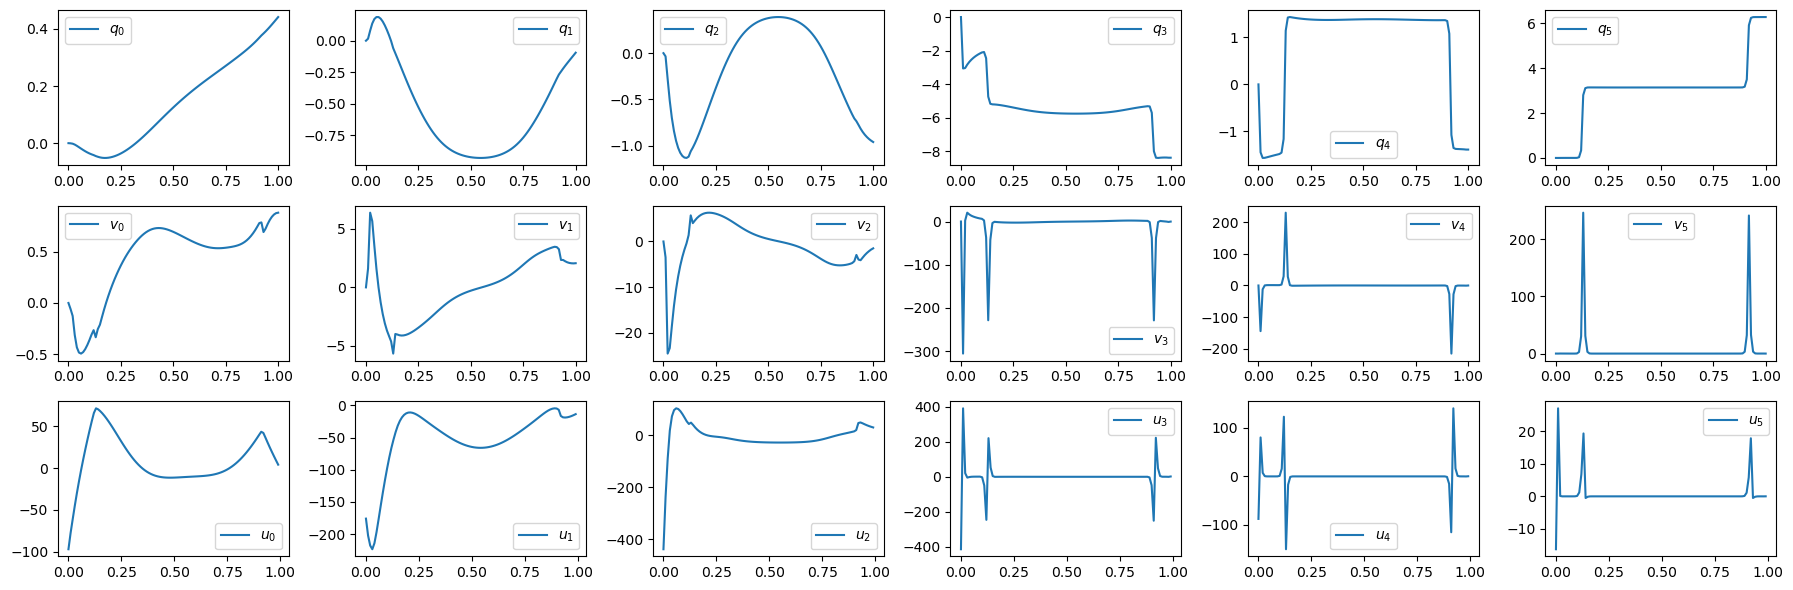

In [52]:
show_results(log)
plot_results(log)

### 1.2 Add joint limits (angles, velocities, torques) as box inequality constraints

We will consider 
- the state (angles and velocities) limits as soft constraints, otherwise we will need to install additional solvers to handle state limits
- the input (torques) constraints as hard inequality constraints, since this can be handeled by crocoddyl's SolverBoxFDDP

Let the state limits be $x_{\mathrm{lb}} \leq x_k \leq x_{\mathrm{ub}}$, where
$$
x_{\mathrm{lb}} =
\begin{bmatrix}
q_{\min} \\
- v_{\max}
\end{bmatrix},
\qquad
x_{\mathrm{ub}} =
\begin{bmatrix}
q_{\max} \\
v_{\max}
\end{bmatrix}.
$$
and the control input limit be $u_{\mathrm{lb}} \leq u_k \leq u_{\mathrm{ub}}$.

Let $\ell_{\mathrm{xlim}}(x_k,x_{\mathrm{lb}},x_{\mathrm{ub}})$ be the quadratic barrier activation function associated with these state limits.

Then, the running cost is now
$$
\ell_k(x_k,x_{k,\mathrm{target}},u_k) = w_t \cdot \ell_{\mathrm{track}}(x_k,x_{k,\mathrm{target}}) + w_x \cdot \ell_{x,\mathrm{reg}}(x_k) + w_u \cdot \ell_u(u_k) + w_{xl}\cdot \ell_{\mathrm{xlim}}(x_k,x_{\mathrm{lb}},x_{\mathrm{ub}})
$$
and the terminal cost is
$$
\ell_T(x_T,x_{T,\mathrm{target}}) = w_t \cdot \ell_{\mathrm{track}}(x_T,x_{T,\mathrm{target}}) + w_x \cdot \ell_{x,\mathrm{reg}}(x_T) + w_{xl}\cdot \ell_{\mathrm{xlim}}(x_T,x_{\mathrm{lb}},x_{\mathrm{ub}}),
$$
where $w_t, w_x, w_u, w_{xl}$ are weights selected by the user.

Then, the optimal control problem becomes
$$
\min_{\{x_k\}_{k=1}^{T},\,\{u_k\}_{k=0}^{T-1}}
\sum_{k=0}^{T-1} \ell_k(x_k,x_{k,\mathrm{target}},u_k) + \ell_T(x_T,x_{T,\mathrm{target}})
$$

subject to
$$
x_{k+1} = f(x_k,u_k), \qquad k = 0,\dots,T-1,
$$

$$
x_0 = x_{\mathrm{ref}}
$$

$$
u_{\mathrm{lb}} \leq u_k \leq u_{\mathrm{ub}}, \qquad k = 0,\dots,T-1.
$$

In [53]:
# Parameters
nv = robot.model.nv
nu = nv
dt = 0.01
T = 100 # number of time steps

# State and actuation models
state = crocoddyl.StateMultibody(robot.model)
actuation = crocoddyl.ActuationModelFull(state)

# Reference for state regularization
q0 = pin.neutral(robot.model)
x0 = np.concatenate([q0, pin.utils.zero(nv)])

# Running costs that are the same for all time steps
# - Input regularization
uRegRes = crocoddyl.ResidualModelJointEffort(state, actuation, nu)
uRegCost = crocoddyl.CostModelResidual(state, uRegRes)
# - State regularization
xRegAct = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost = crocoddyl.CostModelResidual(state, xRegAct, xRegRes)

# State Limits (positions and velocities box limits)
# Activation bounds are the limits beyond which a quadratic penalty will be applied
xLim = crocoddyl.ActivationBounds(
    np.concatenate([robot.model.lowerPositionLimit, -robot.model.velocityLimit]), # <-- lower bounds
    np.concatenate([robot.model.upperPositionLimit,  robot.model.velocityLimit]), # <-- upper bounds
    beta=1., # <-- if you make this smaller, then the penalty starts even before you exceed the limits
)
xLimAct = crocoddyl.ActivationModelQuadraticBarrier(xLim)
xLimRes = crocoddyl.ResidualModelState(state, np.zeros(state.nx), nu)
xLimCost = crocoddyl.CostModelResidual(state, xLimAct, xLimRes)

# Running models
t_current = 0.0
runningModels = []
target_id = state.pinocchio.getFrameId('ee_link')
for i in range(T):
    # Running cost at time step i
    trackRes_i = crocoddyl.ResidualModelFramePlacement(
        state,
        target_id,
        compute_target(t_current + i * dt), # placeholder; will be modified later to track the circle
        nu,
    )
    trackCost_i = crocoddyl.CostModelResidual(state, trackRes_i)
    
    # Total running cost at time step i (sum of individual costs)
    costModel_i = crocoddyl.CostModelSum(state)
    costModel_i.addCost('track', trackCost_i, 1e1)
    costModel_i.addCost('xReg', xRegCost, 1e-4)
    costModel_i.addCost('uReg', uRegCost, 1e-5)
    costModel_i.addCost('xLim', xLimCost, 1e2) # state limit costs

    # Dynamic model at time step i (no external contact constraints)
    dam_i = crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_i
    )

    # Running model at time step i (use Euler integration)
    runningModel_i = crocoddyl.IntegratedActionModelEuler(dam_i, dt)
    
    # Add torque limits to the running model
    runningModel_i.u_lb = -robot.model.effortLimit
    runningModel_i.u_ub =  robot.model.effortLimit
    runningModels.append(runningModel_i)

# Terminal cost
# - State regularization
xRegAct_T = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes_T = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost_T = crocoddyl.CostModelResidual(state, xRegAct_T, xRegRes_T)
# - Tracking
trackRes_T = crocoddyl.ResidualModelFramePlacement(
    state,
    target_id,
    compute_target(t_current + T * dt),
    nu,
)
trackCost_T = crocoddyl.CostModelResidual(state, trackRes_T)

# Terminal model
costModel_T = crocoddyl.CostModelSum(state)
costModel_T.addCost('track', trackCost_T, 1e1)
costModel_T.addCost('xReg', xRegCost_T, 1e-4)
costModel_T.addCost('xLim', xLimCost, 1e2) # state limit costs
terminalModel = crocoddyl.IntegratedActionModelEuler(
    crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_T
    ),
    0.,
)
terminalModel.u_lb = -robot.model.effortLimit
terminalModel.u_ub =  robot.model.effortLimit

# Problem and solver
problem = crocoddyl.ShootingProblem(x0, runningModels, terminalModel)
solver = crocoddyl.SolverBoxFDDP(problem)

# Make the solver verbose
#solver.setCallbacks([crocoddyl.CallbackVerbose()])
solver.setCallbacks([])

Solve optimal control problem

converge =  True


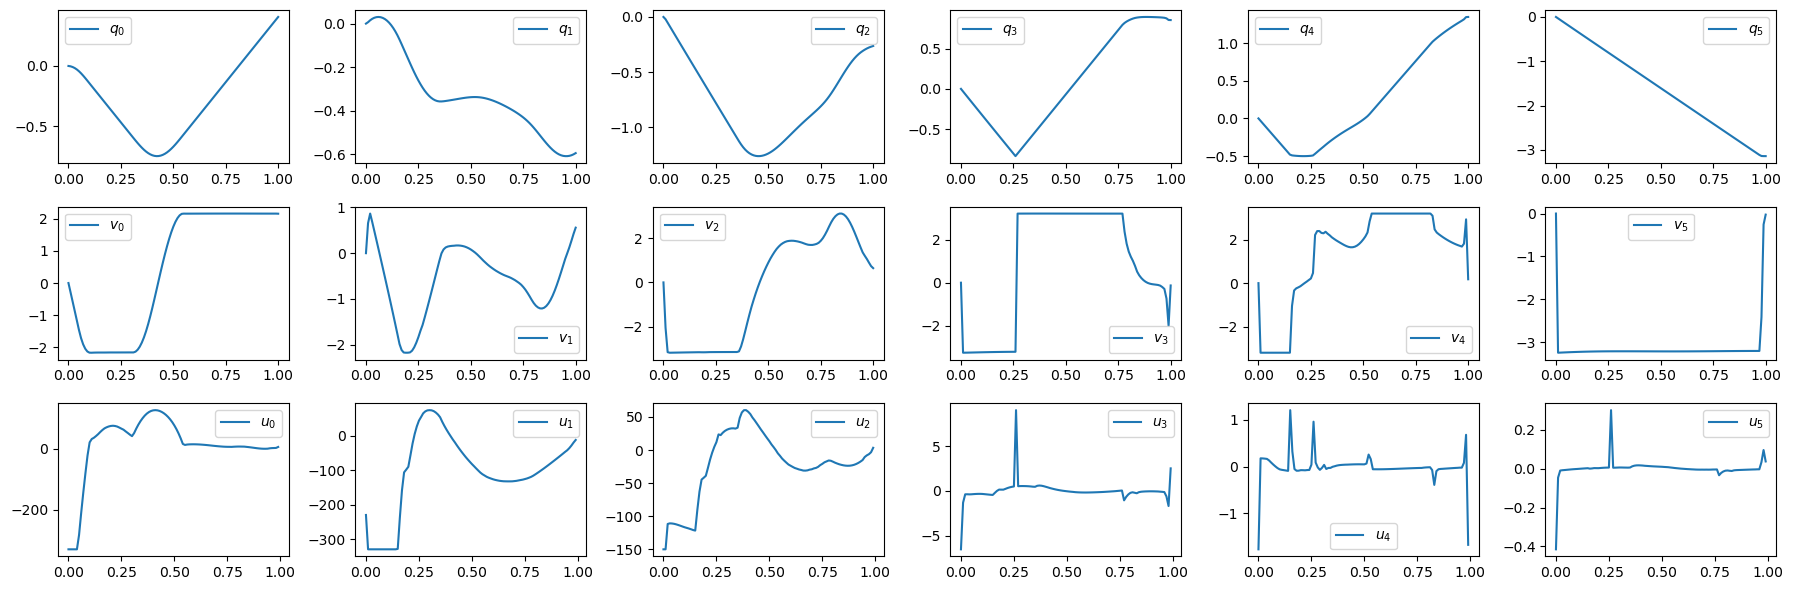

In [54]:
# Initial guess
xs_init = [x0.copy() for _ in range(T + 1)]          # state trajectory guess
us_init = [np.zeros(nu) for _ in range(T)]           # control trajectory guess

# Solve problem
success = solver.solve(
    xs_init,
    us_init,
    300,
)
# Check for success
converged = solver.isFeasible and solver.stop < solver.th_stop
print("converge = ", converged)

# Put results in a log
log = {
    't': np.array([t_current + i * dt for i in range(T + 1)]),
    'x': np.array(solver.xs),
    'u': np.array(solver.us),
}

# Show and plot results
show_results(log)
plot_results(log)

### 1.3 Add self-collisions as quadratic barrier functions in the cost

Let $\mathcal{C}_{\mathrm{self}}$ be the set of self-collision pairs.

Let $\sum_{c\in\mathcal{C}_{\mathrm{self}}} \ell_{\mathrm{sc}}(x_k,c)$ be the quadratic barrier activation function associated with all self collision paris.

Then, the running cost is now
$$
\ell_k(x_k,x_{k,\mathrm{target}},u_k) = w_t \cdot \ell_{\mathrm{track}}(x_k,x_{k,\mathrm{target}}) + w_x \cdot \ell_{x,\mathrm{reg}}(x_k) + w_u \cdot \ell_u(u_k) + w_{xl}\cdot \ell_{\mathrm{xlim}}(x_k,x_{\mathrm{lb}},x_{\mathrm{ub}}) + w_{sc}\cdot\sum_{c\in\mathcal{C}_{\mathrm{self}}} \ell_{\mathrm{sc}}(x_k,c)
$$
and the terminal cost is
$$
\ell_T(x_T,x_{T,\mathrm{target}}) = w_t \cdot \ell_{\mathrm{track}}(x_T,x_{T,\mathrm{target}}) + w_x \cdot \ell_{x,\mathrm{reg}}(x_T) + w_{xl}\cdot \ell_{\mathrm{xlim}}(x_T,x_{\mathrm{lb}},x_{\mathrm{ub}}) + w_{sc}\cdot\sum_{c\in\mathcal{C}_{\mathrm{self}}} \ell_{\mathrm{sc}}(x_T,c),
$$
where $w_t, w_x, w_u, w_{xl}, w_{sc}$ are weights selected by the user.

Then, the optimal control problem becomes
$$
\min_{\{x_k\}_{k=1}^{T},\,\{u_k\}_{k=0}^{T-1}}
\sum_{k=0}^{T-1} \ell_k(x_k,x_{k,\mathrm{target}},u_k) + \ell_T(x_T,x_{T,\mathrm{target}})
$$

subject to
$$
x_{k+1} = f(x_k,u_k), \qquad k = 0,\dots,T-1,
$$

$$
x_0 = x_{\mathrm{ref}}
$$

$$
u_{\mathrm{lb}} \leq u_k \leq u_{\mathrm{ub}}, \qquad k = 0,\dots,T-1.
$$

In [55]:
# Parameters
nv = robot.model.nv
nu = nv
dt = 0.01
T = 100 # number of time steps

# State and actuation models
state = crocoddyl.StateMultibody(robot.model)
actuation = crocoddyl.ActuationModelFull(state)

# Reference for state regularization
q0 = pin.neutral(robot.model)
x0 = np.concatenate([q0, pin.utils.zero(nv)])

# Running costs that are the same for all time steps
# - Input regularization
uRegRes = crocoddyl.ResidualModelJointEffort(state, actuation, nu)
uRegCost = crocoddyl.CostModelResidual(state, uRegRes)
# - State regularization
xRegAct = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost = crocoddyl.CostModelResidual(state, xRegAct, xRegRes)

# State Limits (positions and velocities box limits)
# Activation bounds are the limits beyond which a quadratic penalty will be applied
xLim = crocoddyl.ActivationBounds(
    np.concatenate([robot.model.lowerPositionLimit, -robot.model.velocityLimit]), # <-- lower bounds
    np.concatenate([robot.model.upperPositionLimit,  robot.model.velocityLimit]), # <-- upper bounds
    beta=1., # <-- if you make this smaller, then the penalty starts even before you exceed the limits
)
xLimAct = crocoddyl.ActivationModelQuadraticBarrier(xLim)
xLimRes = crocoddyl.ResidualModelState(state, np.zeros(state.nx), nu)
xLimCost = crocoddyl.CostModelResidual(state, xLimAct, xLimRes)

# Collision costs
collisionCosts = []
# Append a cost model to the list for each collision pair
for i, pair in enumerate(robot.collision_model.collisionPairs):
    # Activation
    collisionAct = crocoddyl.ActivationModel2NormBarrier(
        3,      # <-- residual has three components (distance to collision in 3D)
        0.02,   # <-- quadratic barrier begins when distance is less than this threshold (meters)
    )

    # Residual
    collisionRes = crocoddyl.ResidualModelPairCollision(
        state,
        nu,
        robot.collision_model,
        i,          # index of the collision pair
        pair.first, # index of first geometry object (determines which frame is used)
    )

    # Cost
    collisionCost = crocoddyl.CostModelResidual(state, collisionAct, collisionRes)

    # Append to list
    collisionCosts.append(collisionCost)

# Running models
t_current = 0.0
runningModels = []
target_id = state.pinocchio.getFrameId('ee_link')
for i in range(T):
    # Running cost at time step i
    trackRes_i = crocoddyl.ResidualModelFramePlacement(
        state,
        target_id,
        compute_target(t_current + i * dt), # placeholder; will be modified later to track the circle
        nu,
    )
    trackCost_i = crocoddyl.CostModelResidual(state, trackRes_i)
    
    # Total running cost at time step i (sum of individual costs)
    costModel_i = crocoddyl.CostModelSum(state)
    costModel_i.addCost('track', trackCost_i, 1e1)
    costModel_i.addCost('xReg', xRegCost, 1e-4)
    costModel_i.addCost('uReg', uRegCost, 1e-5)
    costModel_i.addCost('xLim', xLimCost, 1e2) # state limit costs
    for k in range(len(robot.collision_model.collisionPairs)):
        costModel_i.addCost(f'selfCollision_{k}', collisionCosts[k], 1e1)

    # Dynamic model at time step i (no external contact constraints)
    dam_i = crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_i
    )

    # Running model at time step i (use Euler integration)
    runningModel_i = crocoddyl.IntegratedActionModelEuler(dam_i, dt)
    
    # Add torque limits to the running model
    runningModel_i.u_lb = -robot.model.effortLimit
    runningModel_i.u_ub =  robot.model.effortLimit
    runningModels.append(runningModel_i)

# Terminal cost
# - State regularization
xRegAct_T = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes_T = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost_T = crocoddyl.CostModelResidual(state, xRegAct_T, xRegRes_T)
# - Tracking
trackRes_T = crocoddyl.ResidualModelFramePlacement(
    state,
    target_id,
    compute_target(t_current + T * dt),
    nu,
)
trackCost_T = crocoddyl.CostModelResidual(state, trackRes_T)

# Terminal model
costModel_T = crocoddyl.CostModelSum(state)
costModel_T.addCost('track', trackCost_T, 1e1)
costModel_T.addCost('xReg', xRegCost_T, 1e-4)
costModel_T.addCost('xLim', xLimCost, 1e2) # state limit costs
for k in range(len(robot.collision_model.collisionPairs)):
    costModel_T.addCost(f'selfCollision_{k}', collisionCosts[k], 1e1)
terminalModel = crocoddyl.IntegratedActionModelEuler(
    crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_T
    ),
    0.,
)
terminalModel.u_lb = -robot.model.effortLimit
terminalModel.u_ub =  robot.model.effortLimit

# Problem and solver
problem = crocoddyl.ShootingProblem(x0, runningModels, terminalModel)
solver = crocoddyl.SolverBoxFDDP(problem)

# Make the solver verbose
#solver.setCallbacks([crocoddyl.CallbackVerbose()])
solver.setCallbacks([])

Solve optimal control problem

converge =  True


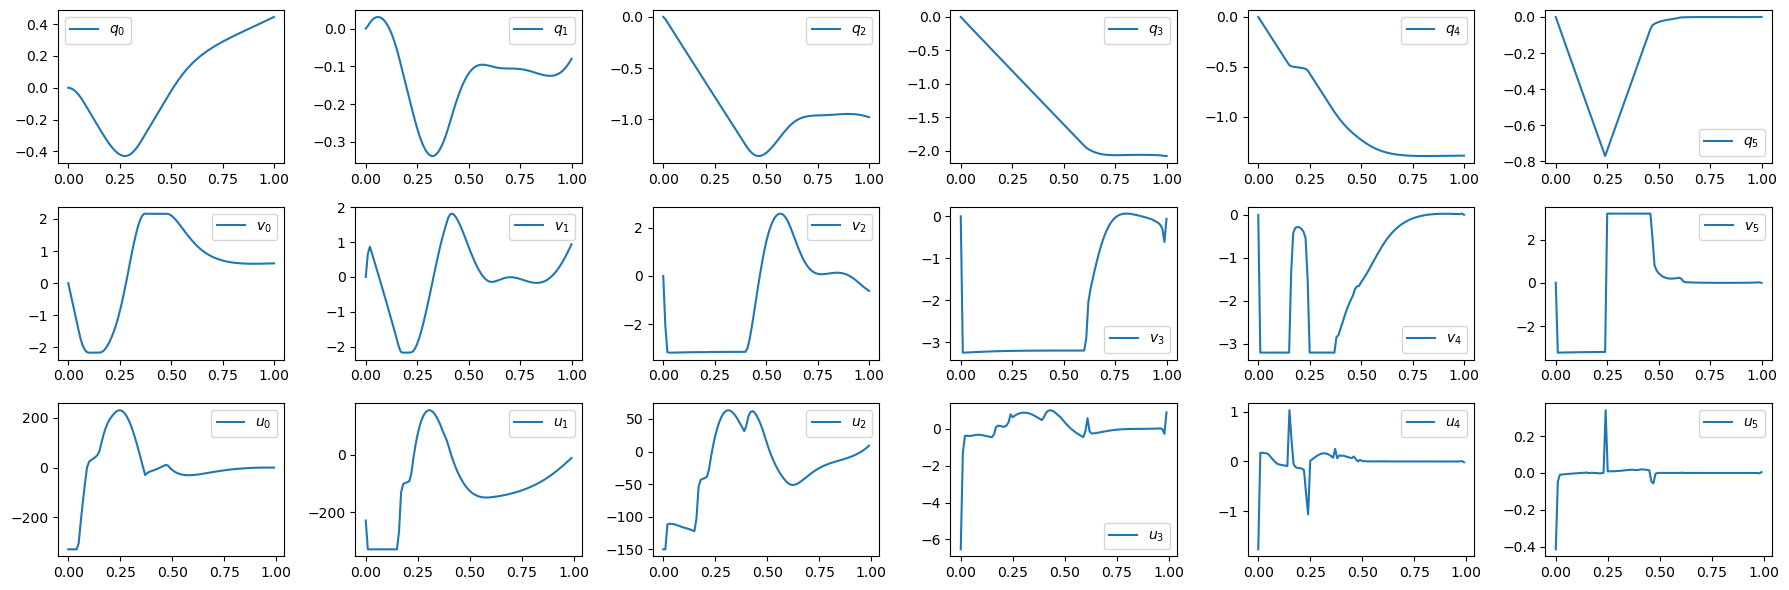

In [56]:
# Initial guess
xs_init = [x0.copy() for _ in range(T + 1)]          # state trajectory guess
us_init = [np.zeros(nu) for _ in range(T)]           # control trajectory guess

# Solve problem
success = solver.solve(
    xs_init,
    us_init,
    300,
)
# Check for success
converged = solver.isFeasible and solver.stop < solver.th_stop
print("converge = ", converged)

# Put results in a log
log = {
    't': np.array([t_current + i * dt for i in range(T + 1)]),
    'x': np.array(solver.xs),
    'u': np.array(solver.us),
}

# Show and plot results
show_results(log)
plot_results(log)

### 1.4 Add a single obstacle somewhere along the circle as a quadratic barrier function in the cost

Let
- $\mathcal{C}_{\mathrm{self}}$ be the set of self-collision pairs,
- $\mathcal{C}_{\mathrm{obs}}$ be the set of robot-obstacle collision pairs.

Let 
- $\sum_{c\in\mathcal{C}_{\mathrm{self}}} \ell_{\mathrm{sc}}(x_k,c)$ be the quadratic barrier activation function associated with all self collision paris
- $\sum_{c\in\mathcal{C}_{\mathrm{obs}}} \ell_{\mathrm{obs}}(x_k,c)$ be the quadratic barrier activation function associated with all obstacles

Then, the running cost is now
$$
\ell_k(x_k,x_{k,\mathrm{target}},u_k) = w_t \cdot \ell_{\mathrm{track}}(x_k,x_{k,\mathrm{target}}) + w_x \cdot \ell_{x,\mathrm{reg}}(x_k) + w_u \cdot \ell_u(u_k) + w_{xl}\cdot \ell_{\mathrm{xlim}}(x_k,x_{\mathrm{lb}},x_{\mathrm{ub}}) + w_{sc}\cdot\sum_{c\in\mathcal{C}_{\mathrm{self}}} \ell_{\mathrm{sc}}(x_k,c) + w_{obs}\cdot \sum_{c\in\mathcal{C}_{\mathrm{obs}}} \ell_{\mathrm{obs}}(x_k,c)
$$
and the terminal cost is
$$
\ell_T(x_T,x_{T,\mathrm{target}}) = w_t \cdot \ell_{\mathrm{track}}(x_T,x_{T,\mathrm{target}}) + w_x \cdot \ell_{x,\mathrm{reg}}(x_T) + w_{xl}\cdot \ell_{\mathrm{xlim}}(x_T,x_{\mathrm{lb}},x_{\mathrm{ub}}) + w_{sc}\cdot\sum_{c\in\mathcal{C}_{\mathrm{self}}} \ell_{\mathrm{sc}}(x_T,c) + w_{obs}\cdot \sum_{c\in\mathcal{C}_{\mathrm{obs}}} \ell_{\mathrm{obs}}(x_T,c),
$$
where $w_t, w_x, w_u, w_{xl}, w_{sc}, w_{obs}$ are weights selected by the user.

Then, the optimal control problem becomes
$$
\min_{\{x_k\}_{k=1}^{T},\,\{u_k\}_{k=0}^{T-1}}
\sum_{k=0}^{T-1} \ell_k(x_k,x_{k,\mathrm{target}},u_k) + \ell_T(x_T,x_{T,\mathrm{target}})
$$

subject to
$$
x_{k+1} = f(x_k,u_k), \qquad k = 0,\dots,T-1,
$$

$$
x_0 = x_{\mathrm{ref}}
$$

$$
u_{\mathrm{lb}} \leq u_k \leq u_{\mathrm{ub}}, \qquad k = 0,\dots,T-1.
$$

Add obstacles and enable checking for collision with them

In [ ]:
# Remove previous obstacles named 'obs*' (safer than relying on counts)
obs_to_remove = [go.name for go in robot.collision_model.geometryObjects if go.name.startswith('obs')]

# Remove all collision pairs that reference those obstacles
for pair in list(robot.collision_model.collisionPairs):
    name1 = robot.collision_model.geometryObjects[pair.first].name
    name2 = robot.collision_model.geometryObjects[pair.second].name
    if name1 in obs_to_remove or name2 in obs_to_remove:
        try:
            robot.collision_model.removeCollisionPair(pair)
        except Exception:
            pass

# Remove geometry and visual objects for those obstacles
for name in obs_to_remove:
    try:
        robot.collision_model.removeGeometryObject(name)
    except Exception:
        pass
    try:
        robot.visual_model.removeGeometryObject(name)
    except Exception:
        pass

# Recompute the number of robot-only geometry objects (everything remaining is robot)
n_robot_geoms = len(robot.collision_model.geometryObjects)

# Add NEW obstacles
xyz_ypr_test = [
    [0.0, 1.0, 0.8, 0.0, 0.0, 0.0],
]

rad_len_test = [
    [0.1, 0.1],
]

rgba = np.array([1.0, 0.2, 0.2, 1.0])

# Add new obstacles
for i, (xyz_ypr_i, rad_len_i) in enumerate(zip(xyz_ypr_test, rad_len_test)):
    obs = pin.GeometryObject.CreateCapsule(rad_len_i[0], rad_len_i[1])
    obs.meshColor = rgba
    obs.name = f'obs{i}'
    obs.parentJoint = 0
    obs.placement = XYZYPRtoSE3(xyz_ypr_i)
    robot.collision_model.addGeometryObject(obs)
    robot.visual_model.addGeometryObject(obs)

# Add collision pairs for all obstacles (robot geoms x new obs geoms)
for i in range(n_robot_geoms):
    for j in range(n_robot_geoms, len(robot.collision_model.geometryObjects)):
        robot.collision_model.addCollisionPair(pin.CollisionPair(i, j))

# Update robot data
robot.data = robot.model.createData()
robot.collision_data = robot.collision_model.createData()
robot.visual_data = robot.visual_model.createData()

# Show all collision pairs again
#for i, pair in enumerate(robot.collision_model.collisionPairs):
#    print(f'{i:2d} : {pair.first:2d} x {pair.second:2d} ({robot.collision_model.geometryObjects[pair.first].name} x {robot.collision_model.geometryObjects[pair.second].name})')

# Convert all collision geometries to convex meshes
for geom_obj in robot.collision_model.geometryObjects:
    geom = geom_obj.geometry
    if isinstance(geom, coal.Convex):
        # Already a convex object, no conversion needed
        pass
    elif isinstance(geom, coal.ShapeBase):
        convex = primitive_to_convex(geom)
        geom_obj.geometry = convex
    elif isinstance(geom, coal.BVHModelBase):
        geom.buildConvexHull(True, 'Qt')
        geom_obj.geometry = geom.convex

# Update robot data after conversion
robot.data = robot.model.createData()
robot.collision_data = robot.collision_model.createData()
robot.visual_data = robot.visual_model.createData()

# Display robot in browser
# Create a visualizer
vis = MeshcatVisualizer(robot.model, robot.collision_model, robot.visual_model)
robot.setVisualizer(vis, init=False)
vis.initViewer(open=True)
vis.loadViewerModel()

# Pause to allow meshcat initialization to finish
time.sleep(0.1)

# Choose what to display
vis.displayFrames(False)
# Switch from showing "visual" geometry to showing "collision" geometry
vis.displayVisuals(False)
vis.displayCollisions(True)

# Pause to allow meshcat initialization to finish
time.sleep(0.1)

# Change the camera view
vis.setCameraPosition(np.array([0., 2., 0.75]))
vis.setCameraTarget(np.array([0., 0., 0.75]))

# Set to neutral position
q = pin.neutral(robot.model)
print(f'{q = }')

# Forward kinematics
pin.forwardKinematics(robot.model, robot.data, q)
pin.updateFramePlacements(robot.model, robot.data)

vis.display(q)

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7004/static/
q = array([0., 0., 0., 0., 0., 0.])


/usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found


/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found
/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'http://127.0.0.1:7004/static/'


In [62]:
# Parameters
nv = robot.model.nv
nu = nv
dt = 0.01
T = 200 # number of time steps

# State and actuation models
state = crocoddyl.StateMultibody(robot.model)
actuation = crocoddyl.ActuationModelFull(state)

# Reference for state regularization
q0 = pin.neutral(robot.model)
x0 = np.concatenate([q0, pin.utils.zero(nv)])

# Running costs that are the same for all time steps
# - Input regularization
uRegRes = crocoddyl.ResidualModelJointEffort(state, actuation, nu)
uRegCost = crocoddyl.CostModelResidual(state, uRegRes)
# - State regularization
xRegAct = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost = crocoddyl.CostModelResidual(state, xRegAct, xRegRes)

# State Limits (positions and velocities box limits)
xLim = crocoddyl.ActivationBounds(
    np.concatenate([robot.model.lowerPositionLimit, -robot.model.velocityLimit]), # <-- lower bounds
    np.concatenate([robot.model.upperPositionLimit,  robot.model.velocityLimit]), # <-- upper bounds
    beta=1., 
)
xLimAct = crocoddyl.ActivationModelQuadraticBarrier(xLim)
xLimRes = crocoddyl.ResidualModelState(state, np.zeros(state.nx), nu)
xLimCost = crocoddyl.CostModelResidual(state, xLimAct, xLimRes)

collisionCosts = []
for i, pair in enumerate(robot.collision_model.collisionPairs):
    # Get the geometry objects involved in this collision pair
    geom1 = robot.collision_model.geometryObjects[pair.first]
    geom2 = robot.collision_model.geometryObjects[pair.second]
    
    # Determine if this pair involves the newly added obstacle
    is_obstacle_pair = ('obs' in geom1.name) or ('obs' in geom2.name)

    # Activation (You can use a larger safe distance threshold for the obstacle if desired)
    safe_distance = 0.05 if is_obstacle_pair else 0.02
    collisionAct = crocoddyl.ActivationModel2NormBarrier(
        3,             # <-- residual has three components (distance to collision in 3D)
        safe_distance, # <-- quadratic barrier begins when distance is less than this threshold
    )

    # joint index
    joint_id = geom1.parentJoint

    # Residual
    collisionRes = crocoddyl.ResidualModelPairCollision(
        state,
        nu,
        robot.collision_model,
        i,          # index of the collision pair
        joint_id,   # joint index of the first geometry
    )

    # Cost
    collisionCost = crocoddyl.CostModelResidual(state, collisionAct, collisionRes)

    # Store cost along with a dynamic name and weight
    cost_name = f'obsCollision_{i}' if is_obstacle_pair else f'selfCollision_{i}'
    cost_weight = 1e2 if is_obstacle_pair else 1e1 # Give the obstacle a higher penalty weight
    
    collisionCosts.append({
        'model': collisionCost,
        'name': cost_name,
        'weight': cost_weight
    })

# Running models
t_current = 0.0
runningModels = []
target_id = state.pinocchio.getFrameId('ee_link')
for i in range(T):
    # Running cost at time step i
    trackRes_i = crocoddyl.ResidualModelFramePlacement(
        state,
        target_id,
        compute_target(t_current + i * dt), 
        nu,
    )
    trackCost_i = crocoddyl.CostModelResidual(state, trackRes_i)
    
    # Total running cost at time step i
    costModel_i = crocoddyl.CostModelSum(state)
    costModel_i.addCost('track', trackCost_i, 1e1)
    costModel_i.addCost('xReg', xRegCost, 1e-4)
    costModel_i.addCost('uReg', uRegCost, 1e-5)
    costModel_i.addCost('xLim', xLimCost, 1e2) # state limit costs
    
    # Add all evaluated collision costs (Self + Obstacle)
    for c in collisionCosts:
        costModel_i.addCost(c['name'], c['model'], c['weight'])

    # Dynamic model at time step i
    dam_i = crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_i
    )

    # Running model at time step i
    runningModel_i = crocoddyl.IntegratedActionModelEuler(dam_i, dt)
    runningModel_i.u_lb = -robot.model.effortLimit
    runningModel_i.u_ub =  robot.model.effortLimit
    runningModels.append(runningModel_i)

# Terminal cost
xRegAct_T = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes_T = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost_T = crocoddyl.CostModelResidual(state, xRegAct_T, xRegRes_T)

trackRes_T = crocoddyl.ResidualModelFramePlacement(
    state,
    target_id,
    compute_target(t_current + T * dt),
    nu,
)
trackCost_T = crocoddyl.CostModelResidual(state, trackRes_T)

# Terminal model
costModel_T = crocoddyl.CostModelSum(state)
costModel_T.addCost('track', trackCost_T, 1e1)
costModel_T.addCost('xReg', xRegCost_T, 1e-4)
costModel_T.addCost('xLim', xLimCost, 1e2) 

# Add all evaluated collision costs to the terminal model as well
for c in collisionCosts:
    costModel_T.addCost(c['name'], c['model'], c['weight'])

terminalModel = crocoddyl.IntegratedActionModelEuler(
    crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_T
    ),
    0.,
)
terminalModel.u_lb = -robot.model.effortLimit
terminalModel.u_ub =  robot.model.effortLimit

# Problem and solver
problem = crocoddyl.ShootingProblem(x0, runningModels, terminalModel)
solver = crocoddyl.SolverBoxFDDP(problem)

# Make the solver verbose
#solver.setCallbacks([crocoddyl.CallbackVerbose()])
solver.setCallbacks([])

Solve optimal control problem

converge =  True


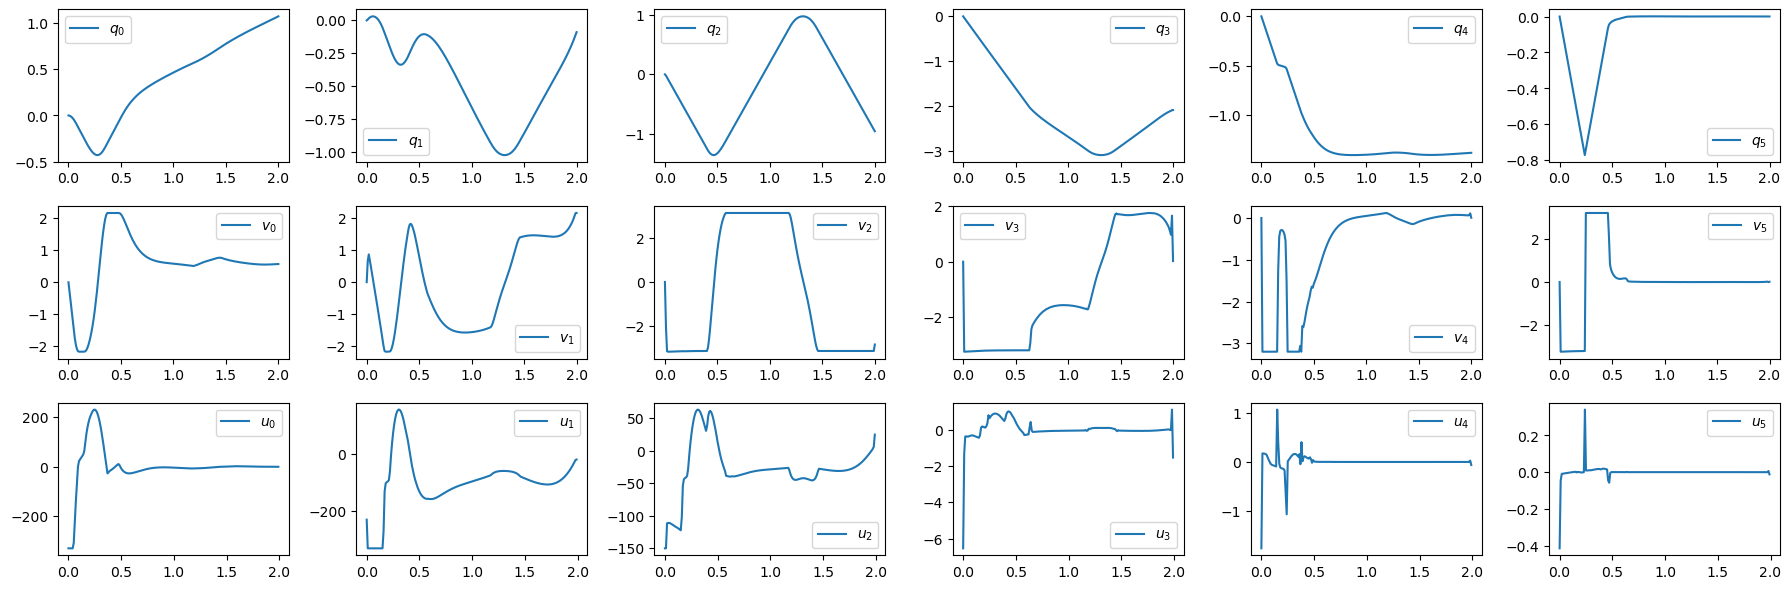

In [64]:
# Initial guess
xs_init = [x0.copy() for _ in range(T + 1)]          # state trajectory guess
us_init = [np.zeros(nu) for _ in range(T)]           # control trajectory guess

# Solve problem
success = solver.solve(
    xs_init,
    us_init,
    300,
)
# Check for success
converged = solver.isFeasible and solver.stop < solver.th_stop
print("converge = ", converged)

# Put results in a log
log = {
    't': np.array([t_current + i * dt for i in range(T + 1)]),
    'x': np.array(solver.xs),
    'u': np.array(solver.us),
}

# Show and plot results
show_results(log)
plot_results(log)

## 2. Model Predictive Control

We will implement MPC and use it to achieve the goal of moving twice around the circle while avoiding collision and satisfying joint limits:
- For the first time step, use "stationary at the zero configuration" as the initial guess for the optimal control solver
- For all subsequent time steps, use the optimal trajectory at the prior time step as the initial guess of the trajectory at the current time step (i.e., "warm start")
- We will solve the optimal control problem from Section 1.4 in a receding horizon manner (MPC)

First, define the desired circular trajectory of the end-effector, which is a circle of radius 1.0 at $z=0.9$. The period is 2.5 second.

In [70]:
# Function that returns the target pose at (continuous) time t
def compute_target(t):
    # Circle trajectory
    
    radius = 1.0
    period = 5.0
    omega = 2 * np.pi / period
    theta = omega * t
    target_position = np.array([radius * np.cos(theta), radius * np.sin(theta), 0.8])
    target_orientation = np.array([[np.cos(theta), -np.sin(theta), 0.0], 
                                   [np.sin(theta), np.cos(theta), 0.0], 
                                   [0.0, 0.0, 1.0]])
    target_pose = pin.SE3(target_orientation, target_position)

    return target_pose

Define the robot dynamics that will be used by the ODE solver

In [71]:
def robot_dynamics(x, u):
    q = x[:nv]
    v = x[nv:]
    a = pin.aba(robot.model, robot.data, q, v, u)
    xdot = np.concatenate([v, a])
    return xdot

### 2.1 Case 1: Obstacle at a location that does not interfere with the robot's motion at all

Add obstacles and enable checking for collision with them

In [ ]:
# Remove previous obstacles named 'obs*' (safer than relying on counts)
obs_to_remove = [go.name for go in robot.collision_model.geometryObjects if go.name.startswith('obs')]

# Remove all collision pairs that reference those obstacles
for pair in list(robot.collision_model.collisionPairs):
    name1 = robot.collision_model.geometryObjects[pair.first].name
    name2 = robot.collision_model.geometryObjects[pair.second].name
    if name1 in obs_to_remove or name2 in obs_to_remove:
        try:
            robot.collision_model.removeCollisionPair(pair)
        except Exception:
            pass

# Remove geometry and visual objects for those obstacles
for name in obs_to_remove:
    try:
        robot.collision_model.removeGeometryObject(name)
    except Exception:
        pass
    try:
        robot.visual_model.removeGeometryObject(name)
    except Exception:
        pass

# Recompute the number of robot-only geometry objects (everything remaining is robot)
n_robot_geoms = len(robot.collision_model.geometryObjects)

# Add NEW obstacles
xyz_ypr_test = [
    [0.0, 0.0, 5.0, 0.0, 0.0, 0.0],
]

rad_len_test = [
    [0.1, 0.1],
]

rgba = np.array([1.0, 0.2, 0.2, 1.0])

# Add new obstacles
for i, (xyz_ypr_i, rad_len_i) in enumerate(zip(xyz_ypr_test, rad_len_test)):
    obs = pin.GeometryObject.CreateCapsule(rad_len_i[0], rad_len_i[1])
    obs.meshColor = rgba
    obs.name = f'obs{i}'
    obs.parentJoint = 0
    obs.placement = XYZYPRtoSE3(xyz_ypr_i)
    robot.collision_model.addGeometryObject(obs)
    robot.visual_model.addGeometryObject(obs)

# Add collision pairs for all obstacles (robot geoms x new obs geoms)
for i in range(n_robot_geoms):
    for j in range(n_robot_geoms, len(robot.collision_model.geometryObjects)):
        robot.collision_model.addCollisionPair(pin.CollisionPair(i, j))

# Update robot data
robot.data = robot.model.createData()
robot.collision_data = robot.collision_model.createData()
robot.visual_data = robot.visual_model.createData()

# Show all collision pairs again
#for i, pair in enumerate(robot.collision_model.collisionPairs):
#    print(f'{i:2d} : {pair.first:2d} x {pair.second:2d} ({robot.collision_model.geometryObjects[pair.first].name} x {robot.collision_model.geometryObjects[pair.second].name})')

# Convert all collision geometries to convex meshes
for geom_obj in robot.collision_model.geometryObjects:
    geom = geom_obj.geometry
    if isinstance(geom, coal.Convex):
        # Already a convex object, no conversion needed
        pass
    elif isinstance(geom, coal.ShapeBase):
        convex = primitive_to_convex(geom)
        geom_obj.geometry = convex
    elif isinstance(geom, coal.BVHModelBase):
        geom.buildConvexHull(True, 'Qt')
        geom_obj.geometry = geom.convex

# Update robot data after conversion
robot.data = robot.model.createData()
robot.collision_data = robot.collision_model.createData()
robot.visual_data = robot.visual_model.createData()

# Display robot in browser
# Create a visualizer
vis = MeshcatVisualizer(robot.model, robot.collision_model, robot.visual_model)
robot.setVisualizer(vis, init=False)
vis.initViewer(open=True)
vis.loadViewerModel()

# Pause to allow meshcat initialization to finish
time.sleep(0.1)

# Choose what to display
vis.displayFrames(False)
# Switch from showing "visual" geometry to showing "collision" geometry
vis.displayVisuals(False)
vis.displayCollisions(True)

# Pause to allow meshcat initialization to finish
time.sleep(0.1)

# Change the camera view
vis.setCameraPosition(np.array([0., 2., 0.75]))
vis.setCameraTarget(np.array([0., 0., 0.75]))

# Set to neutral position
q = pin.neutral(robot.model)
print(f'{q = }')

# Forward kinematics
pin.forwardKinematics(robot.model, robot.data, q)
pin.updateFramePlacements(robot.model, robot.data)

vis.display(q)

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7006/static/
q = array([0., 0., 0., 0., 0., 0.])


/usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found
/usr/bin/xdg-open: 882: google-chrome: not found


/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'http://127.0.0.1:7006/static/'


Setup the cost function and the optimization problem

In [73]:
# Parameters
nv = robot.model.nv
nu = nv
dt = 0.01
T = 100 # number of time steps

# State and actuation models
state = crocoddyl.StateMultibody(robot.model)
actuation = crocoddyl.ActuationModelFull(state)

# Reference for state regularization
q0 = pin.neutral(robot.model)
x0 = np.concatenate([q0, pin.utils.zero(nv)])

# Running costs that are the same for all time steps
# - Input regularization
uRegRes = crocoddyl.ResidualModelJointEffort(state, actuation, nu)
uRegCost = crocoddyl.CostModelResidual(state, uRegRes)
# - State regularization
xRegAct = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost = crocoddyl.CostModelResidual(state, xRegAct, xRegRes)

# State Limits (positions and velocities box limits)
xLim = crocoddyl.ActivationBounds(
    np.concatenate([robot.model.lowerPositionLimit, -robot.model.velocityLimit]), # <-- lower bounds
    np.concatenate([robot.model.upperPositionLimit,  robot.model.velocityLimit]), # <-- upper bounds
    beta=1., 
)
xLimAct = crocoddyl.ActivationModelQuadraticBarrier(xLim)
xLimRes = crocoddyl.ResidualModelState(state, np.zeros(state.nx), nu)
xLimCost = crocoddyl.CostModelResidual(state, xLimAct, xLimRes)

collisionCosts = []
for i, pair in enumerate(robot.collision_model.collisionPairs):
    # Get the geometry objects involved in this collision pair
    geom1 = robot.collision_model.geometryObjects[pair.first]
    geom2 = robot.collision_model.geometryObjects[pair.second]
    
    # Determine if this pair involves the newly added obstacle
    is_obstacle_pair = ('obs' in geom1.name) or ('obs' in geom2.name)

    # Activation (You can use a larger safe distance threshold for the obstacle if desired)
    safe_distance = 0.05 if is_obstacle_pair else 0.02
    collisionAct = crocoddyl.ActivationModel2NormBarrier(
        3,             # <-- residual has three components (distance to collision in 3D)
        safe_distance, # <-- quadratic barrier begins when distance is less than this threshold
    )

    # joint index
    joint_id = geom1.parentJoint

    # Residual
    collisionRes = crocoddyl.ResidualModelPairCollision(
        state,
        nu,
        robot.collision_model,
        i,          # index of the collision pair
        joint_id,   # joint index of the first geometry
    )

    # Cost
    collisionCost = crocoddyl.CostModelResidual(state, collisionAct, collisionRes)

    # Store cost along with a dynamic name and weight
    cost_name = f'obsCollision_{i}' if is_obstacle_pair else f'selfCollision_{i}'
    cost_weight = 1e2 if is_obstacle_pair else 1e1 # Give the obstacle a higher penalty weight
    
    collisionCosts.append({
        'model': collisionCost,
        'name': cost_name,
        'weight': cost_weight
    })

# Running models
t_current = 0.0
runningModels = []
target_id = state.pinocchio.getFrameId('ee_link')
for i in range(T):
    # Running cost at time step i
    trackRes_i = crocoddyl.ResidualModelFramePlacement(
        state,
        target_id,
        compute_target(t_current + i * dt), 
        nu,
    )
    trackCost_i = crocoddyl.CostModelResidual(state, trackRes_i)
    
    # Total running cost at time step i
    costModel_i = crocoddyl.CostModelSum(state)
    costModel_i.addCost('track', trackCost_i, 1e1)
    costModel_i.addCost('xReg', xRegCost, 1e-4)
    costModel_i.addCost('uReg', uRegCost, 1e-5)
    costModel_i.addCost('xLim', xLimCost, 1e2) # state limit costs
    
    # Add all evaluated collision costs (Self + Obstacle)
    for c in collisionCosts:
        costModel_i.addCost(c['name'], c['model'], c['weight'])

    # Dynamic model at time step i
    dam_i = crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_i
    )

    # Running model at time step i
    runningModel_i = crocoddyl.IntegratedActionModelEuler(dam_i, dt)
    runningModel_i.u_lb = -robot.model.effortLimit
    runningModel_i.u_ub =  robot.model.effortLimit
    runningModels.append(runningModel_i)

# Terminal cost
xRegAct_T = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes_T = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost_T = crocoddyl.CostModelResidual(state, xRegAct_T, xRegRes_T)

trackRes_T = crocoddyl.ResidualModelFramePlacement(
    state,
    target_id,
    compute_target(t_current + T * dt),
    nu,
)
trackCost_T = crocoddyl.CostModelResidual(state, trackRes_T)

# Terminal model
costModel_T = crocoddyl.CostModelSum(state)
costModel_T.addCost('track', trackCost_T, 1e1)
costModel_T.addCost('xReg', xRegCost_T, 1e-4)
costModel_T.addCost('xLim', xLimCost, 1e2) 

# Add all evaluated collision costs to the terminal model as well
for c in collisionCosts:
    costModel_T.addCost(c['name'], c['model'], c['weight'])

terminalModel = crocoddyl.IntegratedActionModelEuler(
    crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_T
    ),
    0.,
)
terminalModel.u_lb = -robot.model.effortLimit
terminalModel.u_ub =  robot.model.effortLimit

# Problem and solver
problem = crocoddyl.ShootingProblem(x0, runningModels, terminalModel)
solver = crocoddyl.SolverBoxFDDP(problem)

# Make the solver not verbose
solver.setCallbacks([])

Implement MPC loop

In [74]:
x_current = x0.copy()
xs_warm = []
us_warm = []

# Log
log = {
    't': [],
    'x': [x_current.copy()],
    'u': [],
}

K = 1000 # <-- 10 seconds at dt = 1e-2
for k in range(K):
    print("step", k)
    # Get current time
    t_current = k * dt
    log['t'].append(t_current)

    # Update problem
    problem.x0 = x_current
    for i in range(T):
        t = t_current + i * dt
        runningModels[i].differential.costs.costs['track'].cost.residual.reference = compute_target(t)
    terminalModel.differential.costs.costs['track'].cost.residual.reference = compute_target(t_current + T * dt)

    # Solve problem
    if k == 0:
        solver.solve(xs_warm, us_warm, 300)
    else:
        solver.solve(xs_warm, us_warm, 100)

    # Get control input
    u_current = solver.us[0].copy()
    log['u'].append(u_current)

    # Apply control input to simulate one time step
    sol = solve_ivp(
        fun = lambda t, x: robot_dynamics(x, u_current), 
        t_span = [0, dt], 
        y0 = x_current, 
        method = 'RK45'
    )
    x_current = sol.y[:, -1].copy()
    #solver.problem.runningModels[0].calc(solver.problem.runningDatas[0], x_current, u_current)
    #x_current = solver.problem.runningDatas[0].xnext.copy()
    #x_current = solver.xs[1].copy()
    log['x'].append(x_current)

    # Copy and shift the solution for next warm-start
    xs_warm = [solver.xs[i].copy() for i in range(1, T + 1)] + [solver.xs[T].copy()]
    us_warm = [solver.us[i].copy() for i in range(1, T)]     + [solver.us[T - 1].copy()]

# Append final time to log
log['t'].append(K * dt)

# Clean up log
for k in log.keys():
    log[k] = np.array(log[k])

step 0
step 1
step 2
step 3
step 4
step 5
step 6
step 7
step 8
step 9
step 10
step 11
step 12
step 13
step 14
step 15
step 16
step 17
step 18
step 19
step 20
step 21
step 22
step 23
step 24
step 25
step 26
step 27
step 28
step 29
step 30
step 31
step 32
step 33
step 34
step 35
step 36
step 37
step 38
step 39
step 40
step 41
step 42
step 43
step 44
step 45
step 46
step 47
step 48
step 49
step 50
step 51
step 52
step 53
step 54
step 55
step 56
step 57
step 58
step 59
step 60
step 61
step 62
step 63
step 64
step 65
step 66
step 67
step 68
step 69
step 70
step 71
step 72
step 73
step 74
step 75
step 76
step 77
step 78
step 79
step 80
step 81
step 82
step 83
step 84
step 85
step 86
step 87
step 88
step 89
step 90
step 91
step 92
step 93
step 94
step 95
step 96
step 97
step 98
step 99
step 100
step 101
step 102
step 103
step 104
step 105
step 106
step 107
step 108
step 109
step 110
step 111
step 112
step 113
step 114
step 115
step 116
step 117
step 118
step 119
step 120
step 121
step 122
ste

Show and plot results.

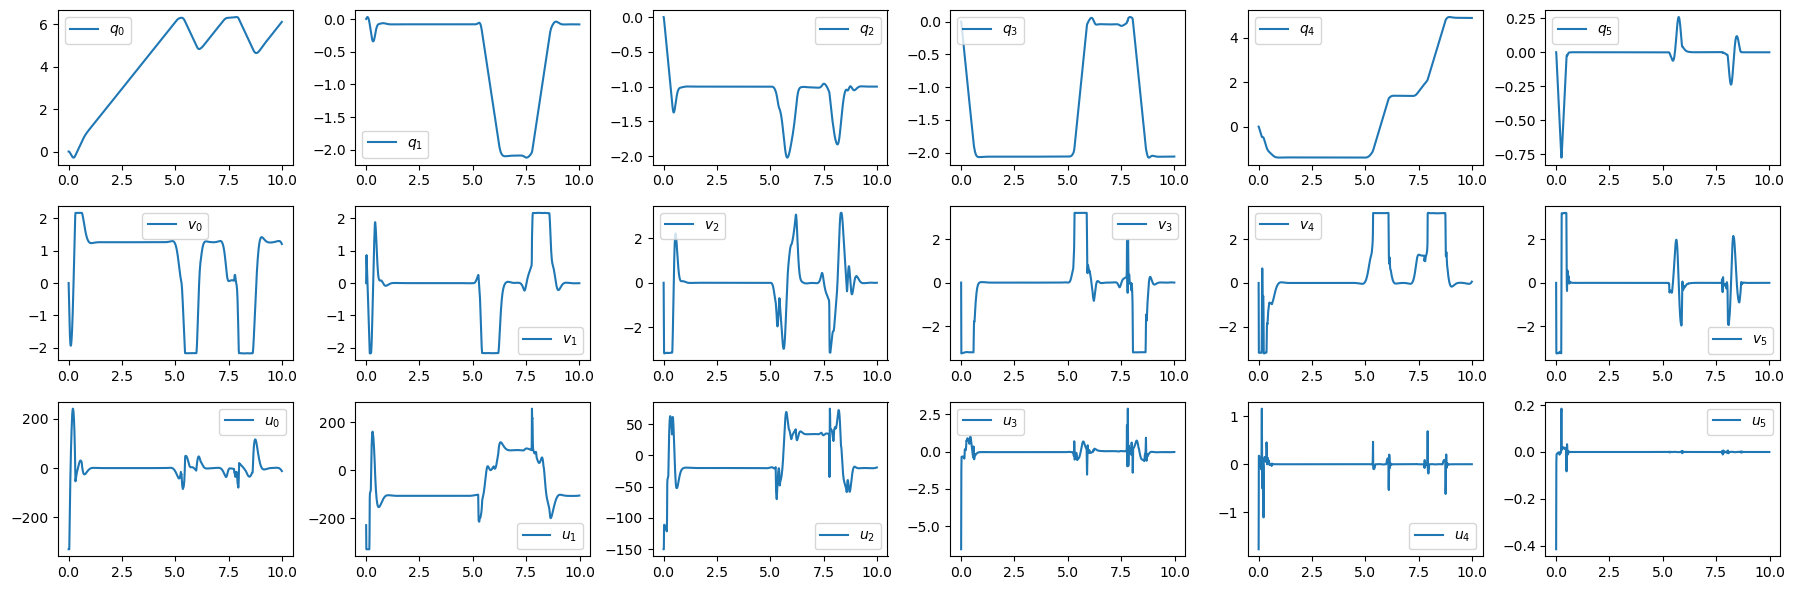

In [75]:
show_results(log)
plot_results(log)

### 2.2 Case 2: Obstacle at a location that interferes with the first optimal trajectory computed by your solver

Add obstacles and enable checking for collision with them

In [ ]:
# Remove previous obstacles named 'obs*' (safer than relying on counts)
obs_to_remove = [go.name for go in robot.collision_model.geometryObjects if go.name.startswith('obs')]

# Remove all collision pairs that reference those obstacles
for pair in list(robot.collision_model.collisionPairs):
    name1 = robot.collision_model.geometryObjects[pair.first].name
    name2 = robot.collision_model.geometryObjects[pair.second].name
    if name1 in obs_to_remove or name2 in obs_to_remove:
        try:
            robot.collision_model.removeCollisionPair(pair)
        except Exception:
            pass

# Remove geometry and visual objects for those obstacles
for name in obs_to_remove:
    try:
        robot.collision_model.removeGeometryObject(name)
    except Exception:
        pass
    try:
        robot.visual_model.removeGeometryObject(name)
    except Exception:
        pass

# Recompute the number of robot-only geometry objects (everything remaining is robot)
n_robot_geoms = len(robot.collision_model.geometryObjects)

# Add NEW obstacles
xyz_ypr_test = [
    [np.cos(2*np.pi/2.5 * 0.8), np.sin(2*np.pi/2.5 * 0.8), 0.8, 0.0, 0.0, 0.0],
]

rad_len_test = [
    [0.1, 0.1],
]

rgba = np.array([1.0, 0.2, 0.2, 1.0])

# Add new obstacles
for i, (xyz_ypr_i, rad_len_i) in enumerate(zip(xyz_ypr_test, rad_len_test)):
    obs = pin.GeometryObject.CreateCapsule(rad_len_i[0], rad_len_i[1])
    obs.meshColor = rgba
    obs.name = f'obs{i}'
    obs.parentJoint = 0
    obs.placement = XYZYPRtoSE3(xyz_ypr_i)
    robot.collision_model.addGeometryObject(obs)
    robot.visual_model.addGeometryObject(obs)

# Add collision pairs for all obstacles (robot geoms x new obs geoms)
for i in range(n_robot_geoms):
    for j in range(n_robot_geoms, len(robot.collision_model.geometryObjects)):
        robot.collision_model.addCollisionPair(pin.CollisionPair(i, j))

# Update robot data
robot.data = robot.model.createData()
robot.collision_data = robot.collision_model.createData()
robot.visual_data = robot.visual_model.createData()

# Show all collision pairs again
#for i, pair in enumerate(robot.collision_model.collisionPairs):
#    print(f'{i:2d} : {pair.first:2d} x {pair.second:2d} ({robot.collision_model.geometryObjects[pair.first].name} x {robot.collision_model.geometryObjects[pair.second].name})')

# Convert all collision geometries to convex meshes
for geom_obj in robot.collision_model.geometryObjects:
    geom = geom_obj.geometry
    if isinstance(geom, coal.Convex):
        # Already a convex object, no conversion needed
        pass
    elif isinstance(geom, coal.ShapeBase):
        convex = primitive_to_convex(geom)
        geom_obj.geometry = convex
    elif isinstance(geom, coal.BVHModelBase):
        geom.buildConvexHull(True, 'Qt')
        geom_obj.geometry = geom.convex

# Update robot data after conversion
robot.data = robot.model.createData()
robot.collision_data = robot.collision_model.createData()
robot.visual_data = robot.visual_model.createData()

# Display robot in browser
# Create a visualizer
vis = MeshcatVisualizer(robot.model, robot.collision_model, robot.visual_model)
robot.setVisualizer(vis, init=False)
vis.initViewer(open=True)
vis.loadViewerModel()

# Pause to allow meshcat initialization to finish
time.sleep(0.1)

# Choose what to display
vis.displayFrames(False)
# Switch from showing "visual" geometry to showing "collision" geometry
vis.displayVisuals(False)
vis.displayCollisions(True)

# Pause to allow meshcat initialization to finish
time.sleep(0.1)

# Change the camera view
vis.setCameraPosition(np.array([0., 2., 0.75]))
vis.setCameraTarget(np.array([0., 0., 0.75]))

# Set to neutral position
q = pin.neutral(robot.model)
print(f'{q = }')

# Forward kinematics
pin.forwardKinematics(robot.model, robot.data, q)
pin.updateFramePlacements(robot.model, robot.data)

vis.display(q)

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7007/static/
q = array([0., 0., 0., 0., 0., 0.])


/usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found


/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'http://127.0.0.1:7007/static/'


Setup the cost function and the optimization problem

In [77]:
# Parameters
nv = robot.model.nv
nu = nv
dt = 0.01
T = 100 # number of time steps

# State and actuation models
state = crocoddyl.StateMultibody(robot.model)
actuation = crocoddyl.ActuationModelFull(state)

# Reference for state regularization
q0 = pin.neutral(robot.model)
x0 = np.concatenate([q0, pin.utils.zero(nv)])

# Running costs that are the same for all time steps
# - Input regularization
uRegRes = crocoddyl.ResidualModelJointEffort(state, actuation, nu)
uRegCost = crocoddyl.CostModelResidual(state, uRegRes)
# - State regularization
xRegAct = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost = crocoddyl.CostModelResidual(state, xRegAct, xRegRes)

# State Limits (positions and velocities box limits)
xLim = crocoddyl.ActivationBounds(
    np.concatenate([robot.model.lowerPositionLimit, -robot.model.velocityLimit]), # <-- lower bounds
    np.concatenate([robot.model.upperPositionLimit,  robot.model.velocityLimit]), # <-- upper bounds
    beta=1., 
)
xLimAct = crocoddyl.ActivationModelQuadraticBarrier(xLim)
xLimRes = crocoddyl.ResidualModelState(state, np.zeros(state.nx), nu)
xLimCost = crocoddyl.CostModelResidual(state, xLimAct, xLimRes)

collisionCosts = []
for i, pair in enumerate(robot.collision_model.collisionPairs):
    # Get the geometry objects involved in this collision pair
    geom1 = robot.collision_model.geometryObjects[pair.first]
    geom2 = robot.collision_model.geometryObjects[pair.second]
    
    # Determine if this pair involves the newly added obstacle
    is_obstacle_pair = ('obs' in geom1.name) or ('obs' in geom2.name)

    # Activation (You can use a larger safe distance threshold for the obstacle if desired)
    safe_distance = 0.05 if is_obstacle_pair else 0.02
    collisionAct = crocoddyl.ActivationModel2NormBarrier(
        3,             # <-- residual has three components (distance to collision in 3D)
        safe_distance, # <-- quadratic barrier begins when distance is less than this threshold
    )

    # joint index
    joint_id = geom1.parentJoint

    # Residual
    collisionRes = crocoddyl.ResidualModelPairCollision(
        state,
        nu,
        robot.collision_model,
        i,          # index of the collision pair
        joint_id,   # joint index of the first geometry
    )

    # Cost
    collisionCost = crocoddyl.CostModelResidual(state, collisionAct, collisionRes)

    # Store cost along with a dynamic name and weight
    cost_name = f'obsCollision_{i}' if is_obstacle_pair else f'selfCollision_{i}'
    cost_weight = 1e2 if is_obstacle_pair else 1e2 # Give the obstacle a higher penalty weight
    
    collisionCosts.append({
        'model': collisionCost,
        'name': cost_name,
        'weight': cost_weight
    })

# Running models
t_current = 0.0
runningModels = []
target_id = state.pinocchio.getFrameId('ee_link')
for i in range(T):
    # Running cost at time step i
    trackRes_i = crocoddyl.ResidualModelFramePlacement(
        state,
        target_id,
        compute_target(t_current + i * dt), 
        nu,
    )
    trackCost_i = crocoddyl.CostModelResidual(state, trackRes_i)
    
    # Total running cost at time step i
    costModel_i = crocoddyl.CostModelSum(state)
    costModel_i.addCost('track', trackCost_i, 1e1)
    costModel_i.addCost('xReg', xRegCost, 1e-4)
    costModel_i.addCost('uReg', uRegCost, 1e-5)
    costModel_i.addCost('xLim', xLimCost, 1e2) # state limit costs
    
    # Add all evaluated collision costs (Self + Obstacle)
    for c in collisionCosts:
        costModel_i.addCost(c['name'], c['model'], c['weight'])

    # Dynamic model at time step i
    dam_i = crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_i
    )

    # Running model at time step i
    runningModel_i = crocoddyl.IntegratedActionModelEuler(dam_i, dt)
    runningModel_i.u_lb = -robot.model.effortLimit
    runningModel_i.u_ub =  robot.model.effortLimit
    runningModels.append(runningModel_i)

# Terminal cost
xRegAct_T = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes_T = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost_T = crocoddyl.CostModelResidual(state, xRegAct_T, xRegRes_T)

trackRes_T = crocoddyl.ResidualModelFramePlacement(
    state,
    target_id,
    compute_target(t_current + T * dt),
    nu,
)
trackCost_T = crocoddyl.CostModelResidual(state, trackRes_T)

# Terminal model
costModel_T = crocoddyl.CostModelSum(state)
costModel_T.addCost('track', trackCost_T, 1e1)
costModel_T.addCost('xReg', xRegCost_T, 1e-4)
costModel_T.addCost('xLim', xLimCost, 1e2) 

# Add all evaluated collision costs to the terminal model as well
for c in collisionCosts:
    costModel_T.addCost(c['name'], c['model'], c['weight'])

terminalModel = crocoddyl.IntegratedActionModelEuler(
    crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_T
    ),
    0.,
)
terminalModel.u_lb = -robot.model.effortLimit
terminalModel.u_ub =  robot.model.effortLimit

# Problem and solver
problem = crocoddyl.ShootingProblem(x0, runningModels, terminalModel)
solver = crocoddyl.SolverBoxFDDP(problem)

# Make the solver not verbose
solver.setCallbacks([])

Implement MPC loop

In [78]:
x_current = x0.copy()
xs_warm = []
us_warm = []

# Log
log = {
    't': [],
    'x': [x_current.copy()],
    'u': [],
}

K = 1000 # <-- 10 seconds at dt = 1e-2
for k in range(K):
    print("step", k)
    # Get current time
    t_current = k * dt
    log['t'].append(t_current)

    # Update problem
    problem.x0 = x_current
    for i in range(T):
        t = t_current + i * dt
        runningModels[i].differential.costs.costs['track'].cost.residual.reference = compute_target(t)
    terminalModel.differential.costs.costs['track'].cost.residual.reference = compute_target(t_current + T * dt)

    # Solve problem
    solver.solve(xs_warm, us_warm, 250)

    # Get control input
    u_current = solver.us[0].copy()
    log['u'].append(u_current)

    # Apply control input to simulate one time step
    sol = solve_ivp(
        fun = lambda t, x: robot_dynamics(x, u_current), 
        t_span = [0, dt], 
        y0 = x_current, 
        method = 'RK45'
    )
    x_current = sol.y[:, -1].copy()
    #solver.problem.runningModels[0].calc(solver.problem.runningDatas[0], x_current, u_current)
    #x_current = solver.problem.runningDatas[0].xnext.copy()
    #x_current = solver.xs[1].copy()
    log['x'].append(x_current)

    # Copy and shift the solution for next warm-start
    xs_warm = [solver.xs[i].copy() for i in range(1, T + 1)] + [solver.xs[T].copy()]
    us_warm = [solver.us[i].copy() for i in range(1, T)]     + [solver.us[T - 1].copy()]

# Append final time to log
log['t'].append(K * dt)

# Clean up log
for k in log.keys():
    log[k] = np.array(log[k])

step 0
step 1
step 2
step 3
step 4
step 5
step 6
step 7
step 8
step 9
step 10
step 11
step 12
step 13
step 14
step 15
step 16
step 17
step 18
step 19
step 20
step 21
step 22
step 23
step 24
step 25
step 26
step 27
step 28
step 29
step 30
step 31
step 32
step 33
step 34
step 35
step 36
step 37
step 38
step 39
step 40
step 41
step 42
step 43
step 44
step 45
step 46
step 47
step 48
step 49
step 50
step 51
step 52
step 53
step 54
step 55
step 56
step 57
step 58
step 59
step 60
step 61
step 62
step 63
step 64
step 65
step 66
step 67
step 68
step 69
step 70
step 71
step 72
step 73
step 74
step 75
step 76
step 77
step 78
step 79
step 80
step 81
step 82
step 83
step 84
step 85
step 86
step 87
step 88
step 89
step 90
step 91
step 92
step 93
step 94
step 95
step 96
step 97
step 98
step 99
step 100
step 101
step 102
step 103
step 104
step 105
step 106
step 107
step 108
step 109
step 110
step 111
step 112
step 113
step 114
step 115
step 116
step 117
step 118
step 119
step 120
step 121
step 122
ste

Show and plot results.

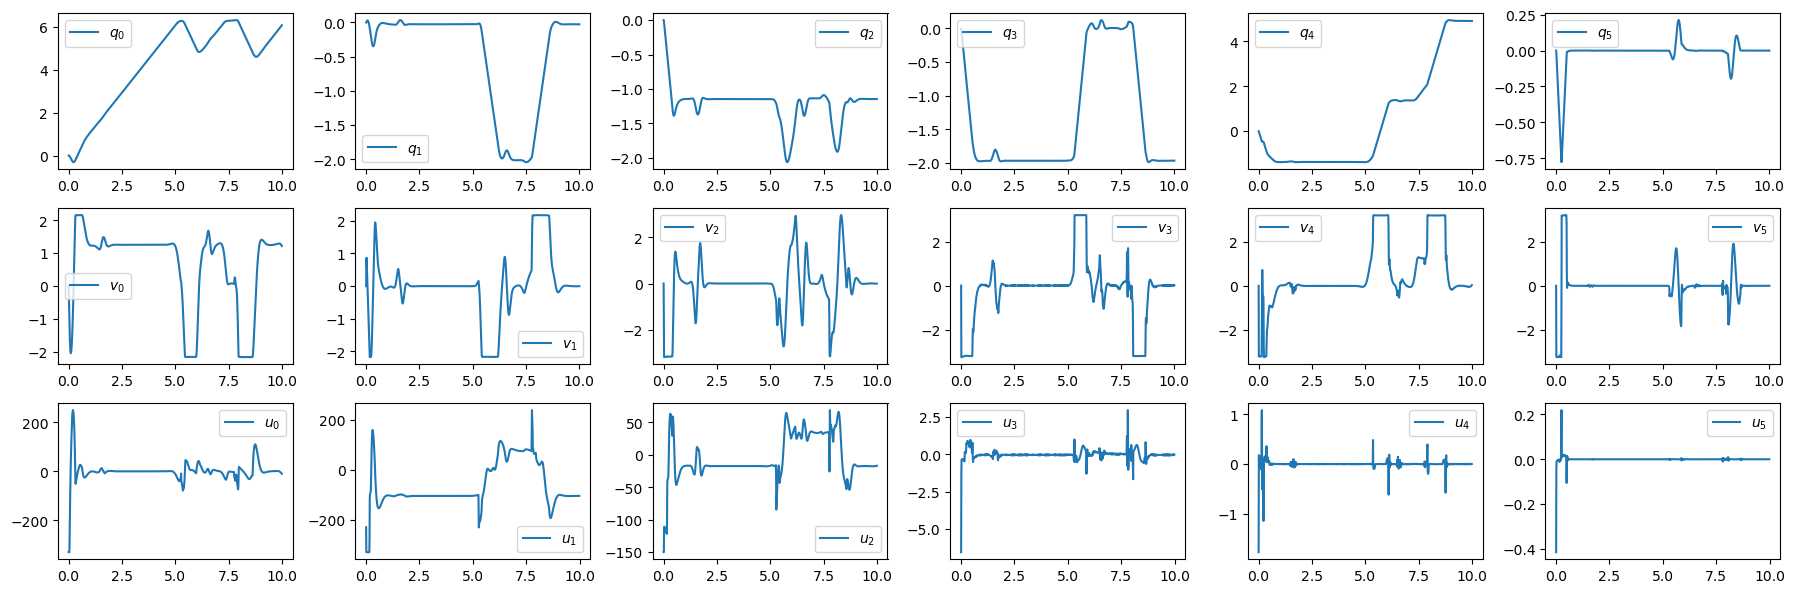

In [79]:
show_results(log)
plot_results(log)

### 2.3 Case 3: Obstacle at a location that interferes with the robot's motion only later on

Add obstacles and enable checking for collision with them

In [ ]:
# Remove previous obstacles named 'obs*' (safer than relying on counts)
obs_to_remove = [go.name for go in robot.collision_model.geometryObjects if go.name.startswith('obs')]

# Remove all collision pairs that reference those obstacles
for pair in list(robot.collision_model.collisionPairs):
    name1 = robot.collision_model.geometryObjects[pair.first].name
    name2 = robot.collision_model.geometryObjects[pair.second].name
    if name1 in obs_to_remove or name2 in obs_to_remove:
        try:
            robot.collision_model.removeCollisionPair(pair)
        except Exception:
            pass

# Remove geometry and visual objects for those obstacles
for name in obs_to_remove:
    try:
        robot.collision_model.removeGeometryObject(name)
    except Exception:
        pass
    try:
        robot.visual_model.removeGeometryObject(name)
    except Exception:
        pass

# Recompute the number of robot-only geometry objects (everything remaining is robot)
n_robot_geoms = len(robot.collision_model.geometryObjects)

# Add NEW obstacles
xyz_ypr_test = [
    [np.cos(2*np.pi/2.5 * 2.2), np.sin(2*np.pi/2.5 * 2.2), 0.8, 0.0, 0.0, 0.0],
]

rad_len_test = [
    [0.1, 0.1],
]

rgba = np.array([1.0, 0.2, 0.2, 1.0])

# Add new obstacles
for i, (xyz_ypr_i, rad_len_i) in enumerate(zip(xyz_ypr_test, rad_len_test)):
    obs = pin.GeometryObject.CreateCapsule(rad_len_i[0], rad_len_i[1])
    obs.meshColor = rgba
    obs.name = f'obs{i}'
    obs.parentJoint = 0
    obs.placement = XYZYPRtoSE3(xyz_ypr_i)
    robot.collision_model.addGeometryObject(obs)
    robot.visual_model.addGeometryObject(obs)

# Add collision pairs for all obstacles (robot geoms x new obs geoms)
for i in range(n_robot_geoms):
    for j in range(n_robot_geoms, len(robot.collision_model.geometryObjects)):
        robot.collision_model.addCollisionPair(pin.CollisionPair(i, j))

# Update robot data
robot.data = robot.model.createData()
robot.collision_data = robot.collision_model.createData()
robot.visual_data = robot.visual_model.createData()

# Show all collision pairs again
#for i, pair in enumerate(robot.collision_model.collisionPairs):
#    print(f'{i:2d} : {pair.first:2d} x {pair.second:2d} ({robot.collision_model.geometryObjects[pair.first].name} x {robot.collision_model.geometryObjects[pair.second].name})')

# Convert all collision geometries to convex meshes
for geom_obj in robot.collision_model.geometryObjects:
    geom = geom_obj.geometry
    if isinstance(geom, coal.Convex):
        # Already a convex object, no conversion needed
        pass
    elif isinstance(geom, coal.ShapeBase):
        convex = primitive_to_convex(geom)
        geom_obj.geometry = convex
    elif isinstance(geom, coal.BVHModelBase):
        geom.buildConvexHull(True, 'Qt')
        geom_obj.geometry = geom.convex

# Update robot data after conversion
robot.data = robot.model.createData()
robot.collision_data = robot.collision_model.createData()
robot.visual_data = robot.visual_model.createData()

# Display robot in browser
# Create a visualizer
vis = MeshcatVisualizer(robot.model, robot.collision_model, robot.visual_model)
robot.setVisualizer(vis, init=False)
vis.initViewer(open=True)
vis.loadViewerModel()

# Pause to allow meshcat initialization to finish
time.sleep(0.1)

# Choose what to display
vis.displayFrames(False)
# Switch from showing "visual" geometry to showing "collision" geometry
vis.displayVisuals(False)
vis.displayCollisions(True)

# Pause to allow meshcat initialization to finish
time.sleep(0.1)

# Change the camera view
vis.setCameraPosition(np.array([0., 2., 0.75]))
vis.setCameraTarget(np.array([0., 0., 0.75]))

# Set to neutral position
q = pin.neutral(robot.model)
print(f'{q = }')

# Forward kinematics
pin.forwardKinematics(robot.model, robot.data, q)
pin.updateFramePlacements(robot.model, robot.data)

vis.display(q)

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7008/static/
q = array([0., 0., 0., 0., 0., 0.])


/usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: konqueror: not found


/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found
/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'http://127.0.0.1:7008/static/'


Setup the cost function and the optimization problem

In [81]:
# Parameters
nv = robot.model.nv
nu = nv
dt = 0.01
T = 100 # number of time steps

# State and actuation models
state = crocoddyl.StateMultibody(robot.model)
actuation = crocoddyl.ActuationModelFull(state)

# Reference for state regularization
q0 = pin.neutral(robot.model)
x0 = np.concatenate([q0, pin.utils.zero(nv)])

# Running costs that are the same for all time steps
# - Input regularization
uRegRes = crocoddyl.ResidualModelJointEffort(state, actuation, nu)
uRegCost = crocoddyl.CostModelResidual(state, uRegRes)
# - State regularization
xRegAct = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost = crocoddyl.CostModelResidual(state, xRegAct, xRegRes)

# State Limits (positions and velocities box limits)
xLim = crocoddyl.ActivationBounds(
    np.concatenate([robot.model.lowerPositionLimit, -robot.model.velocityLimit]), # <-- lower bounds
    np.concatenate([robot.model.upperPositionLimit,  robot.model.velocityLimit]), # <-- upper bounds
    beta=1., 
)
xLimAct = crocoddyl.ActivationModelQuadraticBarrier(xLim)
xLimRes = crocoddyl.ResidualModelState(state, np.zeros(state.nx), nu)
xLimCost = crocoddyl.CostModelResidual(state, xLimAct, xLimRes)

collisionCosts = []
for i, pair in enumerate(robot.collision_model.collisionPairs):
    # Get the geometry objects involved in this collision pair
    geom1 = robot.collision_model.geometryObjects[pair.first]
    geom2 = robot.collision_model.geometryObjects[pair.second]
    
    # Determine if this pair involves the newly added obstacle
    is_obstacle_pair = ('obs' in geom1.name) or ('obs' in geom2.name)

    # Activation (You can use a larger safe distance threshold for the obstacle if desired)
    safe_distance = 0.05 if is_obstacle_pair else 0.02
    collisionAct = crocoddyl.ActivationModel2NormBarrier(
        3,             # <-- residual has three components (distance to collision in 3D)
        safe_distance, # <-- quadratic barrier begins when distance is less than this threshold
    )

    # joint index
    joint_id = geom1.parentJoint

    # Residual
    collisionRes = crocoddyl.ResidualModelPairCollision(
        state,
        nu,
        robot.collision_model,
        i,          # index of the collision pair
        joint_id,   # joint index of the first geometry
    )

    # Cost
    collisionCost = crocoddyl.CostModelResidual(state, collisionAct, collisionRes)

    # Store cost along with a dynamic name and weight
    cost_name = f'obsCollision_{i}' if is_obstacle_pair else f'selfCollision_{i}'
    cost_weight = 1e2 if is_obstacle_pair else 1e2 # Give the obstacle a higher penalty weight
    
    collisionCosts.append({
        'model': collisionCost,
        'name': cost_name,
        'weight': cost_weight
    })

# Running models
t_current = 0.0
runningModels = []
target_id = state.pinocchio.getFrameId('ee_link')
for i in range(T):
    # Running cost at time step i
    trackRes_i = crocoddyl.ResidualModelFramePlacement(
        state,
        target_id,
        compute_target(t_current + i * dt), 
        nu,
    )
    trackCost_i = crocoddyl.CostModelResidual(state, trackRes_i)
    
    # Total running cost at time step i
    costModel_i = crocoddyl.CostModelSum(state)
    costModel_i.addCost('track', trackCost_i, 1e1)
    costModel_i.addCost('xReg', xRegCost, 1e-4)
    costModel_i.addCost('uReg', uRegCost, 1e-5)
    costModel_i.addCost('xLim', xLimCost, 1e2) # state limit costs
    
    # Add all evaluated collision costs (Self + Obstacle)
    for c in collisionCosts:
        costModel_i.addCost(c['name'], c['model'], c['weight'])

    # Dynamic model at time step i
    dam_i = crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_i
    )

    # Running model at time step i
    runningModel_i = crocoddyl.IntegratedActionModelEuler(dam_i, dt)
    runningModel_i.u_lb = -robot.model.effortLimit
    runningModel_i.u_ub =  robot.model.effortLimit
    runningModels.append(runningModel_i)

# Terminal cost
xRegAct_T = crocoddyl.ActivationModelWeightedQuad(
    np.concatenate((1e-1 * np.ones(nv), 1e0 * np.ones(nv)))
)
xRegRes_T = crocoddyl.ResidualModelState(state, x0, nu)
xRegCost_T = crocoddyl.CostModelResidual(state, xRegAct_T, xRegRes_T)

trackRes_T = crocoddyl.ResidualModelFramePlacement(
    state,
    target_id,
    compute_target(t_current + T * dt),
    nu,
)
trackCost_T = crocoddyl.CostModelResidual(state, trackRes_T)

# Terminal model
costModel_T = crocoddyl.CostModelSum(state)
costModel_T.addCost('track', trackCost_T, 1e1)
costModel_T.addCost('xReg', xRegCost_T, 1e-4)
costModel_T.addCost('xLim', xLimCost, 1e2) 

# Add all evaluated collision costs to the terminal model as well
for c in collisionCosts:
    costModel_T.addCost(c['name'], c['model'], c['weight'])

terminalModel = crocoddyl.IntegratedActionModelEuler(
    crocoddyl.DifferentialActionModelFreeFwdDynamics(
        state, actuation, costModel_T
    ),
    0.,
)
terminalModel.u_lb = -robot.model.effortLimit
terminalModel.u_ub =  robot.model.effortLimit

# Problem and solver
problem = crocoddyl.ShootingProblem(x0, runningModels, terminalModel)
solver = crocoddyl.SolverBoxFDDP(problem)

# Make the solver not verbose
solver.setCallbacks([])

Implement MPC loop

In [82]:
x_current = x0.copy()
xs_warm = []
us_warm = []

# Log
log = {
    't': [],
    'x': [x_current.copy()],
    'u': [],
}

K = 1000 # <-- 10 seconds at dt = 1e-2
for k in range(K):
    print("step", k)
    # Get current time
    t_current = k * dt
    log['t'].append(t_current)

    # Update problem
    problem.x0 = x_current
    for i in range(T):
        t = t_current + i * dt
        runningModels[i].differential.costs.costs['track'].cost.residual.reference = compute_target(t)
    terminalModel.differential.costs.costs['track'].cost.residual.reference = compute_target(t_current + T * dt)

    # Solve problem
    solver.solve(xs_warm, us_warm, 250)

    # Get control input
    u_current = solver.us[0].copy()
    log['u'].append(u_current)

    # Apply control input to simulate one time step
    sol = solve_ivp(
        fun = lambda t, x: robot_dynamics(x, u_current), 
        t_span = [0, dt], 
        y0 = x_current, 
        method = 'RK45'
    )
    x_current = sol.y[:, -1].copy()
    #solver.problem.runningModels[0].calc(solver.problem.runningDatas[0], x_current, u_current)
    #x_current = solver.problem.runningDatas[0].xnext.copy()
    #x_current = solver.xs[1].copy()
    log['x'].append(x_current)

    # Copy and shift the solution for next warm-start
    xs_warm = [solver.xs[i].copy() for i in range(1, T + 1)] + [solver.xs[T].copy()]
    us_warm = [solver.us[i].copy() for i in range(1, T)]     + [solver.us[T - 1].copy()]

# Append final time to log
log['t'].append(K * dt)

# Clean up log
for k in log.keys():
    log[k] = np.array(log[k])

step 0
step 1
step 2
step 3
step 4
step 5
step 6
step 7
step 8
step 9
step 10
step 11
step 12
step 13
step 14
step 15
step 16
step 17
step 18
step 19
step 20
step 21
step 22
step 23
step 24
step 25
step 26
step 27
step 28
step 29
step 30
step 31
step 32
step 33
step 34
step 35
step 36
step 37
step 38
step 39
step 40
step 41
step 42
step 43
step 44
step 45
step 46
step 47
step 48
step 49
step 50
step 51
step 52
step 53
step 54
step 55
step 56
step 57
step 58
step 59
step 60
step 61
step 62
step 63
step 64
step 65
step 66
step 67
step 68
step 69
step 70
step 71
step 72
step 73
step 74
step 75
step 76
step 77
step 78
step 79
step 80
step 81
step 82
step 83
step 84
step 85
step 86
step 87
step 88
step 89
step 90
step 91
step 92
step 93
step 94
step 95
step 96
step 97
step 98
step 99
step 100
step 101
step 102
step 103
step 104
step 105
step 106
step 107
step 108
step 109
step 110
step 111
step 112
step 113
step 114
step 115
step 116
step 117
step 118
step 119
step 120
step 121
step 122
ste

Show and plot results.

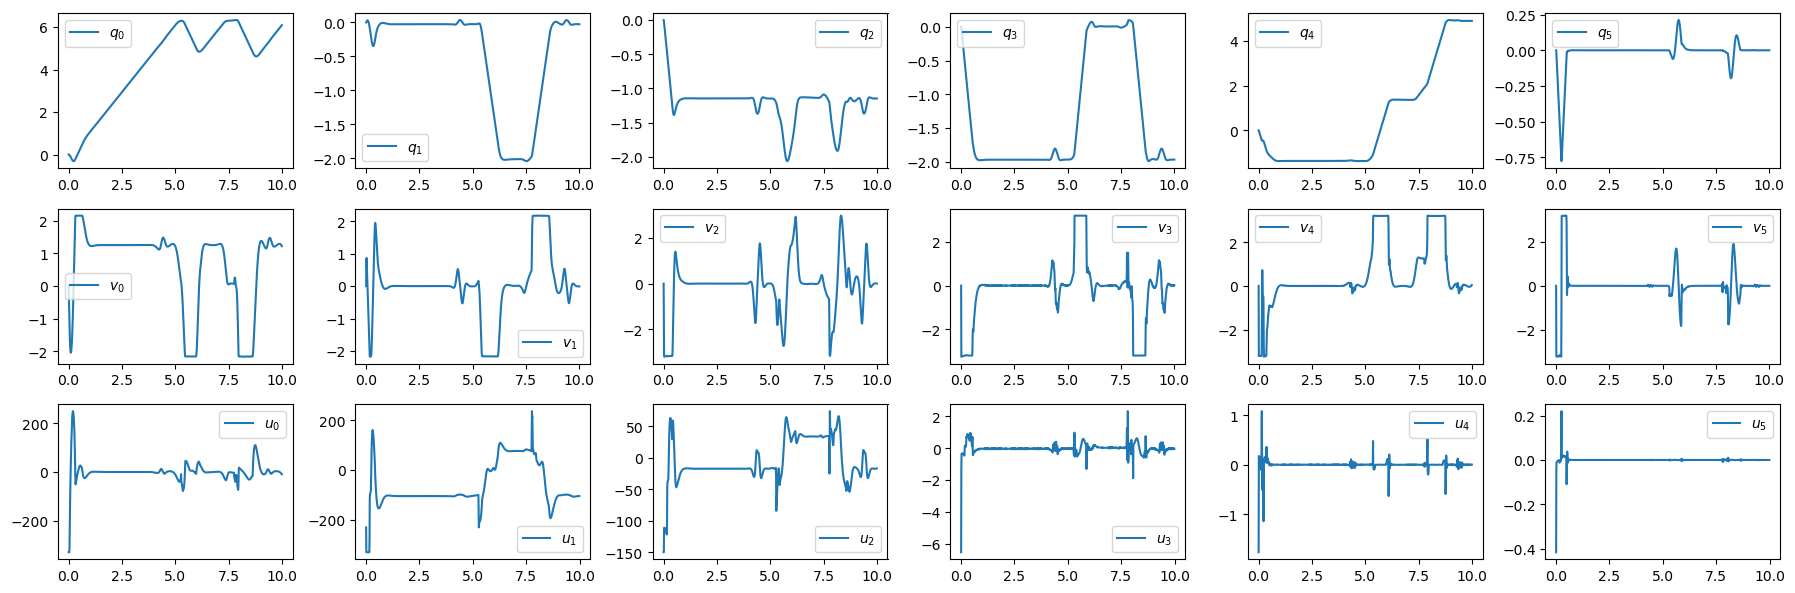

In [83]:
show_results(log)
plot_results(log)